### Project 3: Machine learning and AI in Bioinformatics ###

# Main Task :
 Develop (train) at least two ML classifier (NOT SVM) each that can be used to classify (1)
healthy vs “any cancer” samples (binary) and (2) healthy vs. specific cancer (multi-class).
To avoid statistical errors, make sure the all groups have equal size. (So 4 classifier!)

In [2]:
import pandas as pd

data_path = 'GSE68086_TEP_data_matrix.txt'
df = pd.read_csv(data_path, sep='\t')

print("First 5 rows of the dataset:")
display(df.head())

print("\nInformation about the dataset:")
df.info()

First 5 rows of the dataset:


,Unnamed: 0,3-Breast-Her2-ampl,8-Breast-WT,10-Breast-Her2-ampl,Breast-100,15-Breast-Her2-ampl,16-Breast-WT,21-Breast-WT,33-Breast-Her2-ampl,42-Breast-Her2-ampl,...,MGH-NSCLC-L20-TR500,MGH-NSCLC-L22-TR462,MGH-NSCLC-L23-TR524,MGH-NSCLC-L25-TR480,MGH-NSCLC-L39-TR519,MGH-NSCLC-L40-TR520,MGH-NSCLC-L51-TR521,MGH-NSCLC-L58-TR525,MGH-NSCLC-L59-TR522,MGH-NSCLC-L65-TR523
0,ENSG00000000003,0,0,0,0,17,0,0,0,0,...,0,5,10,9,0,0,0,0,0,0
1,ENSG00000000005,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,ENSG00000000419,44,14,16,8,9,0,139,108,55,...,2,41,40,15,1,0,13,0,0,10
3,ENSG00000000457,26,1,14,0,4,20,1,26,24,...,0,0,0,0,0,0,0,0,0,0
4,ENSG00000000460,81,98,18,17,0,20,144,26,97,...,23,1,6,22,30,0,1,50,6,2



Information about the dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57736 entries, 0 to 57735
Columns: 286 entries, Unnamed: 0 to MGH-NSCLC-L65-TR523
dtypes: int64(285), object(1)
memory usage: 126.0+ MB


In [4]:
# Set 'Unnamed: 0' as index (gene IDs) and then transpose the DataFrame
df_transposed = df.set_index('Unnamed: 0').T

# Extract sample labels from the index (which are now the original column names)
sample_labels = df_transposed.index.to_series()

# Display the first few rows of the transposed DataFrame and its info
print("First 5 rows of the transposed dataset:")
display(df_transposed.head())

print("\nInformation about the transposed dataset:")
df_transposed.info()

print("\nFirst 10 sample labels:")
print(sample_labels.head(10))

First 5 rows of the transposed dataset:


Unnamed: 0,ENSG00000000003,ENSG00000000005,ENSG00000000419,ENSG00000000457,ENSG00000000460,ENSG00000000938,ENSG00000000971,ENSG00000001036,ENSG00000001084,ENSG00000001167,...,ENSG00000273481,ENSG00000273483,ENSG00000273484,ENSG00000273485,ENSG00000273486,ENSG00000273487,ENSG00000273488,ENSG00000273489,ENSG00000273492,ENSG00000273493
3-Breast-Her2-ampl,0,0,44,26,81,171,34,83,0,14,...,0,0,0,0,1,0,0,1,4,0
8-Breast-WT,0,0,14,1,98,99,0,107,0,5,...,0,0,0,0,0,0,0,0,0,0
10-Breast-Her2-ampl,0,0,16,14,18,25,0,62,4,13,...,0,0,0,0,0,0,0,0,0,0
Breast-100,0,0,8,0,17,4,0,19,0,0,...,0,0,0,0,0,0,0,0,0,0
15-Breast-Her2-ampl,17,0,9,4,0,49,0,40,0,10,...,0,0,0,0,0,0,0,0,0,0



Information about the transposed dataset:
<class 'pandas.core.frame.DataFrame'>
Index: 285 entries, 3-Breast-Her2-ampl to MGH-NSCLC-L65-TR523
Columns: 57736 entries, ENSG00000000003 to ENSG00000273493
dtypes: int64(57736)
memory usage: 125.5+ MB

First 10 sample labels:
3-Breast-Her2-ampl      3-Breast-Her2-ampl
8-Breast-WT                    8-Breast-WT
10-Breast-Her2-ampl    10-Breast-Her2-ampl
Breast-100                      Breast-100
15-Breast-Her2-ampl    15-Breast-Her2-ampl
16-Breast-WT                  16-Breast-WT
21-Breast-WT                  21-Breast-WT
33-Breast-Her2-ampl    33-Breast-Her2-ampl
42-Breast-Her2-ampl    42-Breast-Her2-ampl
Breast-454                      Breast-454
dtype: object


In [5]:
# Create a DataFrame for sample metadata
sample_metadata = pd.DataFrame(index=df_transposed.index)
sample_metadata['original_label'] = df_transposed.index

# Refined function to extract cancer type based on common keywords
def extract_cancer_type_refined(label):
    if 'HD' in label or 'Control' in label:
        return 'Healthy'
    elif 'Breast' in label or 'BrCa' in label:
        return 'Breast_Cancer'
    elif 'CRC' in label:
        return 'Colorectal_Cancer'
    elif 'NSCLC' in label or 'Lung' in label:
        return 'NSCLC_Cancer'
    elif 'Gastric' in label:
        return 'Gastric_Cancer'
    elif 'Pancreatic' in label or 'Pancr' in label or 'Panc-' in label:
        return 'Pancreatic_Cancer'
    elif 'Hepatocellular' in label or 'Liver' in label:
        return 'Liver_Cancer'
    elif 'Ovarian' in label:
        return 'Ovarian_Cancer'
    elif 'Esophageal' in label:
        return 'Esophageal_Cancer'
    elif 'Glioblastoma' in label or 'GBM' in label:
        return 'Glioblastoma_Cancer'
    elif 'Renal' in label:
        return 'Renal_Cancer'
    elif 'Urothelial' in label:
        return 'Urothelial_Cancer'
    elif 'Prostate' in label:
        return 'Prostate_Cancer'
    elif 'Chol' in label:
        return 'Cholangiocarcinoma_Cancer'
    else:
        return 'Unknown_Cancer_Type' # Fallback for any unknown type

sample_metadata['cancer_type'] = sample_metadata['original_label'].apply(extract_cancer_type_refined)

# Create binary label for 'healthy vs. any cancer'
sample_metadata['is_healthy'] = sample_metadata['cancer_type'].apply(lambda x: 1 if x == 'Healthy' else 0)

# Display the first few rows of the metadata and value counts
print("Sample Metadata Head (after refined label extraction):")
display(sample_metadata.head())

print("\nValue counts for cancer_type (after refined label extraction):")
print(sample_metadata['cancer_type'].value_counts())

print("\nValue counts for is_healthy (binary classification):")
print(sample_metadata['is_healthy'].value_counts())

Sample Metadata Head (after refined label extraction):


,original_label,cancer_type,is_healthy
3-Breast-Her2-ampl,3-Breast-Her2-ampl,Breast_Cancer,0
8-Breast-WT,8-Breast-WT,Breast_Cancer,0
10-Breast-Her2-ampl,10-Breast-Her2-ampl,Breast_Cancer,0
Breast-100,Breast-100,Breast_Cancer,0
15-Breast-Her2-ampl,15-Breast-Her2-ampl,Breast_Cancer,0



Value counts for cancer_type (after refined label extraction):
cancer_type
NSCLC_Cancer                 59
Healthy                      54
Colorectal_Cancer            44
Breast_Cancer                38
Glioblastoma_Cancer          38
Pancreatic_Cancer            33
Unknown_Cancer_Type           7
Liver_Cancer                  7
Cholangiocarcinoma_Cancer     5
Name: count, dtype: int64

Value counts for is_healthy (binary classification):
is_healthy
0    231
1     54
Name: count, dtype: int64


In [6]:
# Get the original labels for samples still categorized as 'Unknown_Cancer_Type'
remaining_unknown_labels = sample_metadata[sample_metadata['cancer_type'] == 'Unknown_Cancer_Type']['original_label'].unique()

print("Unique original labels for remaining 'Unknown_Cancer_Type':")
for label in remaining_unknown_labels:
    print(label)

Unique original labels for remaining 'Unknown_Cancer_Type':
Type-Unknown-6
Type-Unknown-1
Type-Unknown-5
VU383Platelet-hiseq
VU394Platelet-hiseq
Type-Unknown-3
Type-Unknown-4


In [7]:
from sklearn.utils import resample
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif

def balance_training_dataframe(df_with_target, target_col='target'):
    min_size = df_with_target[target_col].value_counts().min()
    balanced_parts = []
    for class_label in df_with_target[target_col].unique():
        df_class = df_with_target[df_with_target[target_col] == class_label]
        df_class_sampled = resample(
            df_class,
            replace=False,
            n_samples=min_size,
            random_state=42
        )
        balanced_parts.append(df_class_sampled)
    return pd.concat(balanced_parts)

print("Prepared leakage-safe balancing helper.")


Prepared leakage-safe balancing helper.


In [21]:
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif

# Prepare binary data
X_binary = df_transposed.copy()
y_binary = sample_metadata['is_healthy']

# Split BEFORE balancing
X_train_binary, X_test_binary, y_train_binary, y_test_binary = train_test_split(
    X_binary,
    y_binary,
    test_size=0.3,
    random_state=42,
    stratify=y_binary
)

# Balance training only
train_binary = X_train_binary.copy()
train_binary['target'] = y_train_binary.values
train_binary_balanced = balance_training_dataframe(train_binary)

X_train_binary = train_binary_balanced.drop('target', axis=1)
y_train_binary = train_binary_balanced['target']

# Pipeline
binary_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('selector', SelectKBest(
        score_func=f_classif,
        k=min(500, X_train_binary.shape[1])
    )),
    ('clf', LogisticRegression(
        max_iter=5000,
        random_state=42,
        solver='liblinear'
    ))
])

# CV
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

param_grid = {
    'clf__C': [0.01, 0.1, 1, 10]
}

grid = GridSearchCV(
    binary_pipeline,
    param_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1
)

grid.fit(X_train_binary, y_train_binary)

best_binary_model = grid.best_estimator_

print("Best Parameters:", grid.best_params_)
print("Best CV AUC:", grid.best_score_)

# Final test evaluation
y_pred_binary = best_binary_model.predict(X_test_binary)
y_proba_binary = best_binary_model.predict_proba(X_test_binary)[:, 1]

print("\n--- Tuned Logistic Regression Binary Model ---")
print(f"Accuracy: {accuracy_score(y_test_binary, y_pred_binary):.4f}")

print("\nClassification Report:")
print(classification_report(y_test_binary, y_pred_binary))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_binary, y_pred_binary))


c:\Users\Kompal\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: UserWarning: Features [    1    15    17 ... 57731 57732 57733] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\Kompal\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:113: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


Best Parameters: {'clf__C': 0.1}
Best CV AUC: 0.9125

--- Tuned Logistic Regression Binary Model ---
Accuracy: 0.9070

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.89      0.94        70
           1       0.67      1.00      0.80        16

    accuracy                           0.91        86
   macro avg       0.83      0.94      0.87        86
weighted avg       0.94      0.91      0.91        86


Confusion Matrix:
[[62  8]
 [ 0 16]]


In [22]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.feature_selection import SelectKBest, f_classif

# Random Forest pipeline
rf_pipeline_binary = Pipeline([
    ('selector', SelectKBest(
        score_func=f_classif,
        k=min(500, X_train_binary.shape[1])
    )),
    ('clf', RandomForestClassifier(
        random_state=42
    ))
])

# Cross-validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Hyperparameter tuning
param_grid_rf = {
    'clf__n_estimators': [200, 300],
    'clf__max_depth': [10, 20, None],
    'clf__min_samples_split': [2, 5]
}

grid_rf = GridSearchCV(
    rf_pipeline_binary,
    param_grid_rf,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1
)

# Fit CV model
grid_rf.fit(X_train_binary, y_train_binary)

best_rf_model_binary = grid_rf.best_estimator_

print("Best RF Parameters:", grid_rf.best_params_)
print("Best RF CV AUC:", grid_rf.best_score_)

# Final test evaluation
y_pred_rf_binary = best_rf_model_binary.predict(X_test_binary)
y_proba_rf_binary = best_rf_model_binary.predict_proba(X_test_binary)[:, 1]

print("\n--- Tuned Random Forest Binary Model ---")
print(f"Accuracy: {accuracy_score(y_test_binary, y_pred_rf_binary):.4f}")

print("\nClassification Report:")
print(classification_report(y_test_binary, y_pred_rf_binary))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_binary, y_pred_rf_binary))


c:\Users\Kompal\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: UserWarning: Features [    1    15    17 ... 57731 57732 57733] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\Kompal\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:113: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


Best RF Parameters: {'clf__max_depth': 10, 'clf__min_samples_split': 2, 'clf__n_estimators': 300}
Best RF CV AUC: 0.9125

--- Tuned Random Forest Binary Model ---
Accuracy: 0.9070

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.89      0.94        70
           1       0.67      1.00      0.80        16

    accuracy                           0.91        86
   macro avg       0.83      0.94      0.87        86
weighted avg       0.94      0.91      0.91        86


Confusion Matrix:
[[62  8]
 [ 0 16]]


In [14]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Prepare full multi-class data
multi_mask = ~sample_metadata['cancer_type'].isin([
    'Unknown_Cancer_Type',
    'Cholangiocarcinoma_Cancer'
])

X_multi = df_transposed.loc[multi_mask].copy()
y_multi = sample_metadata.loc[multi_mask, 'cancer_type']

# Train-test split BEFORE balancing
X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(
    X_multi,
    y_multi,
    test_size=0.3,
    random_state=42,
    stratify=y_multi
)

# Balance training set only
train_multi = X_train_multi.copy()
train_multi['target'] = y_train_multi.values
train_multi_balanced = balance_training_dataframe(train_multi)

X_train_multi = train_multi_balanced.drop('target', axis=1)
y_train_multi = train_multi_balanced['target']

# Encode labels
label_encoder = LabelEncoder()

y_train_multi_encoded = label_encoder.fit_transform(y_train_multi)
y_test_multi_encoded = label_encoder.transform(y_test_multi)

# Train XGBoost
xgb_model_multi = XGBClassifier(
    objective='multi:softprob',
    num_class=len(label_encoder.classes_),
    eval_metric='mlogloss',
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    random_state=42
)

xgb_model_multi.fit(X_train_multi, y_train_multi_encoded)

# Predict
y_pred_multi = xgb_model_multi.predict(X_test_multi)

# Evaluation
print("\n--- XGBoost Model for Multi-class Classification ---")
print(f"Accuracy: {accuracy_score(y_test_multi_encoded, y_pred_multi):.4f}")

print("\nClassification Report:")
print(classification_report(
    y_test_multi_encoded,
    y_pred_multi,
    target_names=label_encoder.classes_
))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_multi_encoded, y_pred_multi))



--- XGBoost Model for Multi-class Classification ---
Accuracy: 0.3537

Classification Report:
                     precision    recall  f1-score   support

      Breast_Cancer       0.33      0.25      0.29        12
  Colorectal_Cancer       0.22      0.31      0.26        13
Glioblastoma_Cancer       0.27      0.27      0.27        11
            Healthy       0.64      0.56      0.60        16
       Liver_Cancer       0.50      1.00      0.67         2
       NSCLC_Cancer       0.35      0.39      0.37        18
  Pancreatic_Cancer       0.17      0.10      0.12        10

           accuracy                           0.35        82
          macro avg       0.36      0.41      0.37        82
       weighted avg       0.36      0.35      0.35        82


Confusion Matrix:
[[3 3 2 0 0 2 2]
 [1 4 1 2 0 4 1]
 [0 2 3 0 2 4 0]
 [0 1 4 9 0 2 0]
 [0 0 0 0 2 0 0]
 [2 5 1 1 0 7 2]
 [3 3 0 2 0 1 1]]


In [15]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline

gbc_model_multi = Pipeline([
    ('selector', SelectKBest(score_func=f_classif, k=min(500, X_train_multi.shape[1]))),
    ('clf', GradientBoostingClassifier(random_state=42))
])

gbc_model_multi.fit(X_train_multi, y_train_multi)
y_pred_gbc_multi = gbc_model_multi.predict(X_test_multi)

print("\n--- Gradient Boosting Classifier Model for Multi-class Classification (Healthy vs. Specific Cancers) ---")
print(f"Accuracy: {accuracy_score(y_test_multi, y_pred_gbc_multi):.4f}")
print("\nClassification Report:")
print(classification_report(y_test_multi, y_pred_gbc_multi))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test_multi, y_pred_gbc_multi))


c:\Users\Kompal\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: UserWarning: Features [    1    14    15 ... 57733 57734 57735] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\Kompal\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:113: RuntimeWarning: invalid value encountered in divide
  f = msb / msw



--- Gradient Boosting Classifier Model for Multi-class Classification (Healthy vs. Specific Cancers) ---
Accuracy: 0.3415

Classification Report:
                     precision    recall  f1-score   support

      Breast_Cancer       0.33      0.08      0.13        12
  Colorectal_Cancer       0.24      0.69      0.36        13
Glioblastoma_Cancer       0.20      0.09      0.12        11
            Healthy       0.67      0.62      0.65        16
       Liver_Cancer       0.33      1.00      0.50         2
       NSCLC_Cancer       0.25      0.11      0.15        18
  Pancreatic_Cancer       0.38      0.30      0.33        10

           accuracy                           0.34        82
          macro avg       0.34      0.41      0.32        82
       weighted avg       0.35      0.34      0.31        82


Confusion Matrix:
[[ 1  6  1  0  0  0  4]
 [ 1  9  0  1  0  2  0]
 [ 0  3  1  2  4  1  0]
 [ 0  2  1 10  0  3  0]
 [ 0  0  0  0  2  0  0]
 [ 1 12  1  1  0  2  1]
 [ 0  5  1  1  0

# Task 1:  Model Evaluation

Evaluate your model using a confusion matrix including the accuracy and a ROC
curve (including the AUC value) for training AND validation set.


--- Evaluating Binary Random Forest Model ---

Training Set:
Accuracy: 1.0000
Confusion Matrix:
 [[38  0]
 [ 0 38]]
AUC: 1.0000

Test Set:
Accuracy: 0.9070
Confusion Matrix:
 [[62  8]
 [ 0 16]]
AUC: 0.9750


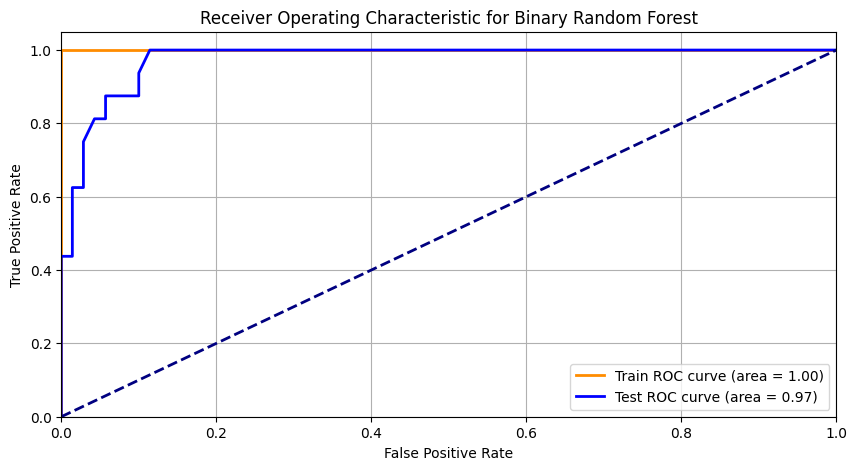

In [24]:
# --- Evaluation for Binary Random Forest Model ---

print("\n--- Evaluating Binary Random Forest Model ---")

# Training Set Evaluation
y_train_pred_rf_binary = rf_model_binary.predict(X_train_binary)
y_train_proba_rf_binary = rf_model_binary.predict_proba(X_train_binary)[:, 1]

print("\nTraining Set:")
print(f"Accuracy: {accuracy_score(y_train_binary, y_train_pred_rf_binary):.4f}")
print("Confusion Matrix:\n", confusion_matrix(y_train_binary, y_train_pred_rf_binary))

# ROC Curve and AUC for Training Set
fpr_train_rf_binary, tpr_train_rf_binary, _ = roc_curve(y_train_binary, y_train_proba_rf_binary)
roc_auc_train_rf_binary = auc(fpr_train_rf_binary, tpr_train_rf_binary)
print(f"AUC: {roc_auc_train_rf_binary:.4f}")

# Test (Validation) Set Evaluation
y_test_pred_rf_binary = rf_model_binary.predict(X_test_binary)
y_test_proba_rf_binary = rf_model_binary.predict_proba(X_test_binary)[:, 1]

print("\nTest Set:")
print(f"Accuracy: {accuracy_score(y_test_binary, y_test_pred_rf_binary):.4f}")
print("Confusion Matrix:\n", confusion_matrix(y_test_binary, y_test_pred_rf_binary))

# ROC Curve and AUC for Test Set
fpr_test_rf_binary, tpr_test_rf_binary, _ = roc_curve(y_test_binary, y_test_proba_rf_binary)
roc_auc_test_rf_binary = auc(fpr_test_rf_binary, tpr_test_rf_binary)
print(f"AUC: {roc_auc_test_rf_binary:.4f}")

# Plotting ROC Curves
plt.figure(figsize=(10, 5))
plt.plot(fpr_train_rf_binary, tpr_train_rf_binary, color='darkorange', lw=2, label=f'Train ROC curve (area = {roc_auc_train_rf_binary:.2f})')
plt.plot(fpr_test_rf_binary, tpr_test_rf_binary, color='blue', lw=2, label=f'Test ROC curve (area = {roc_auc_test_rf_binary:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic for Binary Random Forest')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


--- Evaluating Multi-class XGBoost Model ---

Training Set:
Accuracy: 1.0000

Confusion Matrix:
[[5 0 0 0 0 0 0]
 [0 5 0 0 0 0 0]
 [0 0 5 0 0 0 0]
 [0 0 0 5 0 0 0]
 [0 0 0 0 5 0 0]
 [0 0 0 0 0 5 0]
 [0 0 0 0 0 0 5]]

Classification Report:
                     precision    recall  f1-score   support

      Breast_Cancer       1.00      1.00      1.00         5
  Colorectal_Cancer       1.00      1.00      1.00         5
Glioblastoma_Cancer       1.00      1.00      1.00         5
            Healthy       1.00      1.00      1.00         5
       Liver_Cancer       1.00      1.00      1.00         5
       NSCLC_Cancer       1.00      1.00      1.00         5
  Pancreatic_Cancer       1.00      1.00      1.00         5

           accuracy                           1.00        35
          macro avg       1.00      1.00      1.00        35
       weighted avg       1.00      1.00      1.00        35



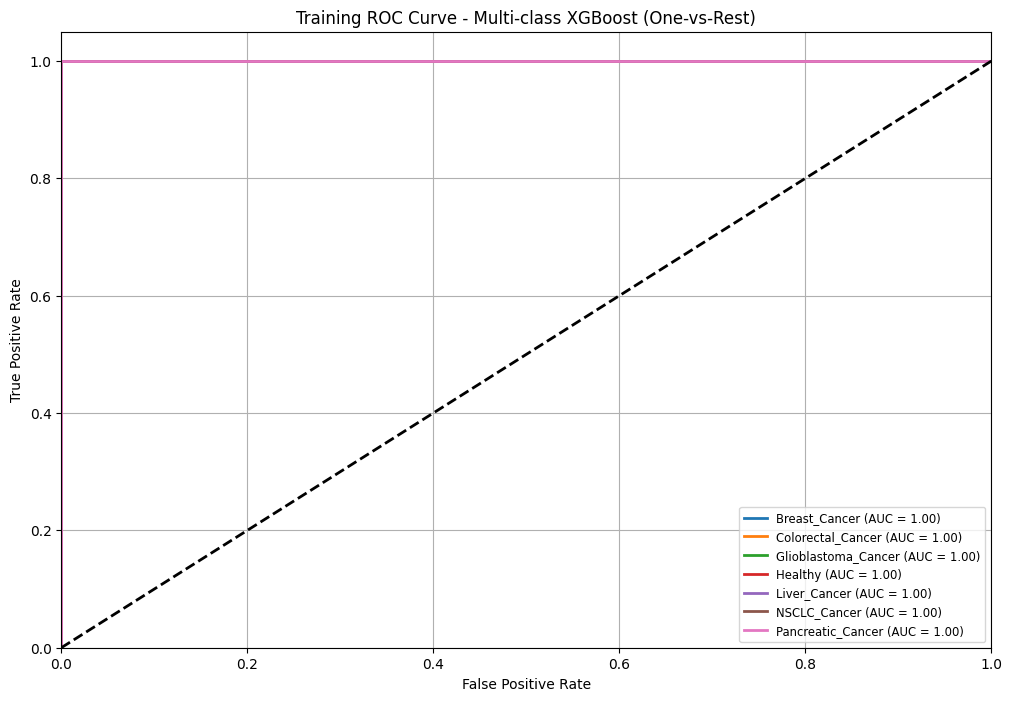


Test Set:
Accuracy: 0.3537

Confusion Matrix:
[[3 3 2 0 0 2 2]
 [1 4 1 2 0 4 1]
 [0 2 3 0 2 4 0]
 [0 1 4 9 0 2 0]
 [0 0 0 0 2 0 0]
 [2 5 1 1 0 7 2]
 [3 3 0 2 0 1 1]]

Classification Report:
                     precision    recall  f1-score   support

      Breast_Cancer       0.33      0.25      0.29        12
  Colorectal_Cancer       0.22      0.31      0.26        13
Glioblastoma_Cancer       0.27      0.27      0.27        11
            Healthy       0.64      0.56      0.60        16
       Liver_Cancer       0.50      1.00      0.67         2
       NSCLC_Cancer       0.35      0.39      0.37        18
  Pancreatic_Cancer       0.17      0.10      0.12        10

           accuracy                           0.35        82
          macro avg       0.36      0.41      0.37        82
       weighted avg       0.36      0.35      0.35        82



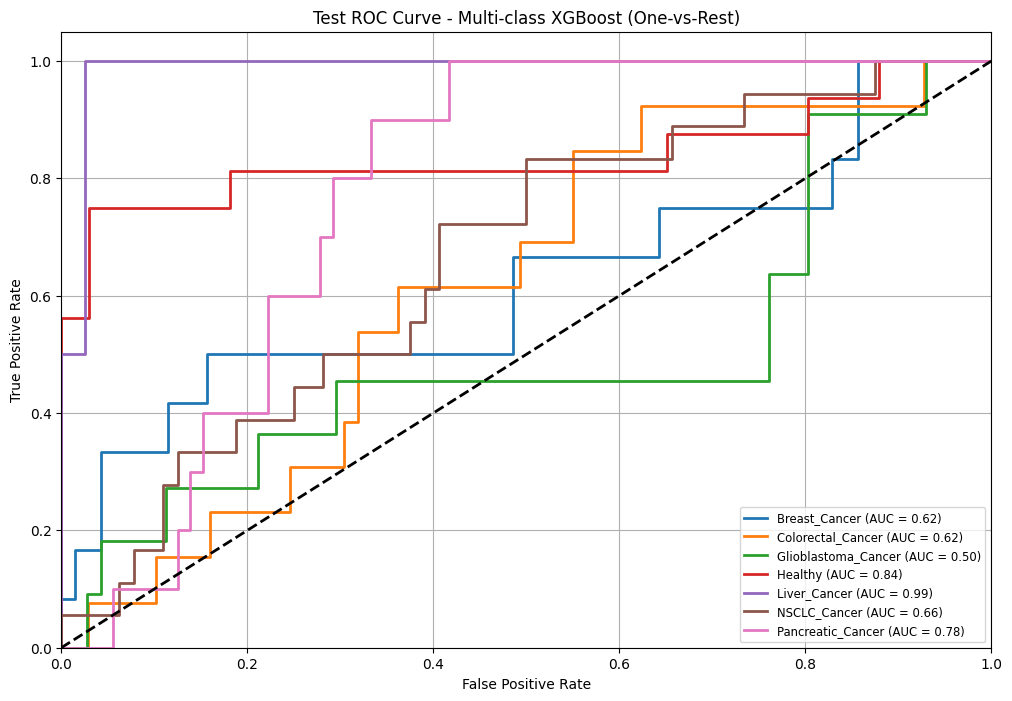

In [18]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)
import matplotlib.pyplot as plt
import numpy as np

print("\n--- Evaluating Multi-class XGBoost Model ---")

# Class labels
classes = label_encoder.classes_
n_classes = len(classes)

# Binarize encoded labels for ROC
y_train_multi_bin = label_binarize(
    y_train_multi_encoded,
    classes=np.arange(n_classes)
)

y_test_multi_bin = label_binarize(
    y_test_multi_encoded,
    classes=np.arange(n_classes)
)

# ===============================
# TRAINING SET EVALUATION
# ===============================
y_train_pred_xgb = xgb_model_multi.predict(X_train_multi)
y_train_proba_xgb = xgb_model_multi.predict_proba(X_train_multi)

print("\nTraining Set:")
print(f"Accuracy: {accuracy_score(y_train_multi_encoded, y_train_pred_xgb):.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_train_multi_encoded, y_train_pred_xgb))

print("\nClassification Report:")
print(classification_report(
    y_train_multi_encoded,
    y_train_pred_xgb,
    target_names=classes
))

# Training ROC
plt.figure(figsize=(12, 8))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(
        y_train_multi_bin[:, i],
        y_train_proba_xgb[:, i]
    )
    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        lw=2,
        label=f'{classes[i]} (AUC = {roc_auc:.2f})'
    )

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0, 1])
plt.ylim([0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Training ROC Curve - Multi-class XGBoost (One-vs-Rest)')
plt.legend(loc='lower right', fontsize='small')
plt.grid(True)
plt.show()

# ===============================
# TEST SET EVALUATION
# ===============================
y_test_pred_xgb = xgb_model_multi.predict(X_test_multi)
y_test_proba_xgb = xgb_model_multi.predict_proba(X_test_multi)

print("\nTest Set:")
print(f"Accuracy: {accuracy_score(y_test_multi_encoded, y_test_pred_xgb):.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_multi_encoded, y_test_pred_xgb))

print("\nClassification Report:")
print(classification_report(
    y_test_multi_encoded,
    y_test_pred_xgb,
    target_names=classes
))

# Test ROC
plt.figure(figsize=(12, 8))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(
        y_test_multi_bin[:, i],
        y_test_proba_xgb[:, i]
    )
    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        lw=2,
        label=f'{classes[i]} (AUC = {roc_auc:.2f})'
    )

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0, 1])
plt.ylim([0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Test ROC Curve - Multi-class XGBoost (One-vs-Rest)')
plt.legend(loc='lower right', fontsize='small')
plt.grid(True)
plt.show()


--- Evaluating Multi-class Gradient Boosting Classifier Model (Healthy vs. Specific Cancers) ---

Training Set:
Accuracy: 1.0000
Confusion Matrix:
 [[5 0 0 0 0 0 0]
 [0 5 0 0 0 0 0]
 [0 0 5 0 0 0 0]
 [0 0 0 5 0 0 0]
 [0 0 0 0 5 0 0]
 [0 0 0 0 0 5 0]
 [0 0 0 0 0 0 5]]


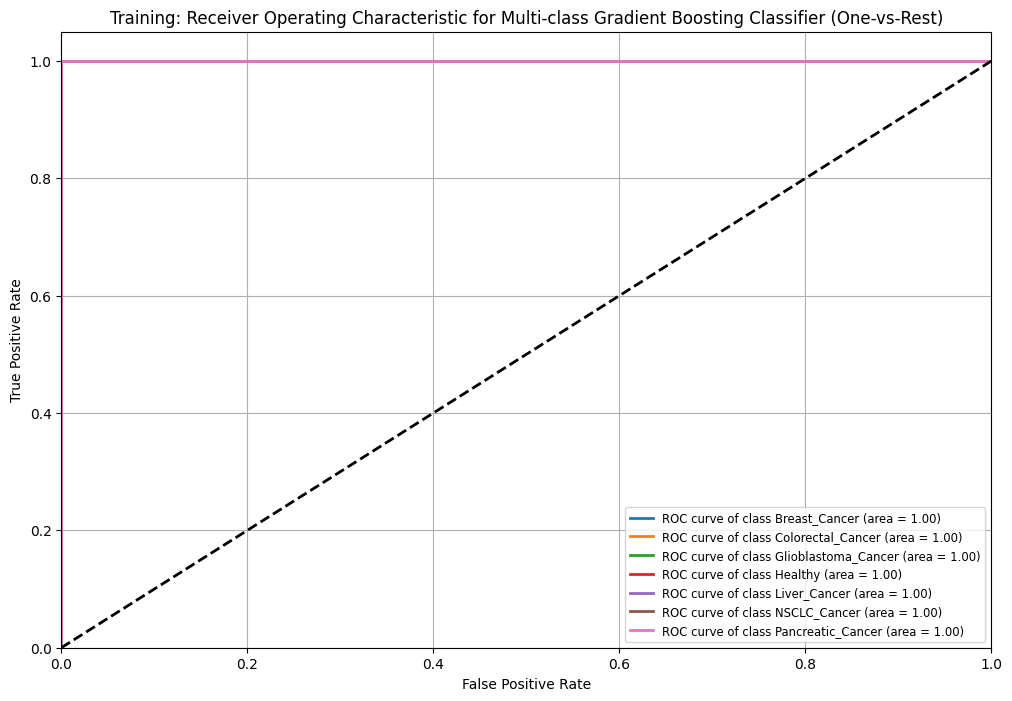


Test Set:
Accuracy: 0.3415
Confusion Matrix:
 [[ 1  6  1  0  0  0  4]
 [ 1  9  0  1  0  2  0]
 [ 0  3  1  2  4  1  0]
 [ 0  2  1 10  0  3  0]
 [ 0  0  0  0  2  0  0]
 [ 1 12  1  1  0  2  1]
 [ 0  5  1  1  0  0  3]]
Classification Report:
                      precision    recall  f1-score   support

      Breast_Cancer       0.33      0.08      0.13        12
  Colorectal_Cancer       0.24      0.69      0.36        13
Glioblastoma_Cancer       0.20      0.09      0.12        11
            Healthy       0.67      0.62      0.65        16
       Liver_Cancer       0.33      1.00      0.50         2
       NSCLC_Cancer       0.25      0.11      0.15        18
  Pancreatic_Cancer       0.38      0.30      0.33        10

           accuracy                           0.34        82
          macro avg       0.34      0.41      0.32        82
       weighted avg       0.35      0.34      0.31        82



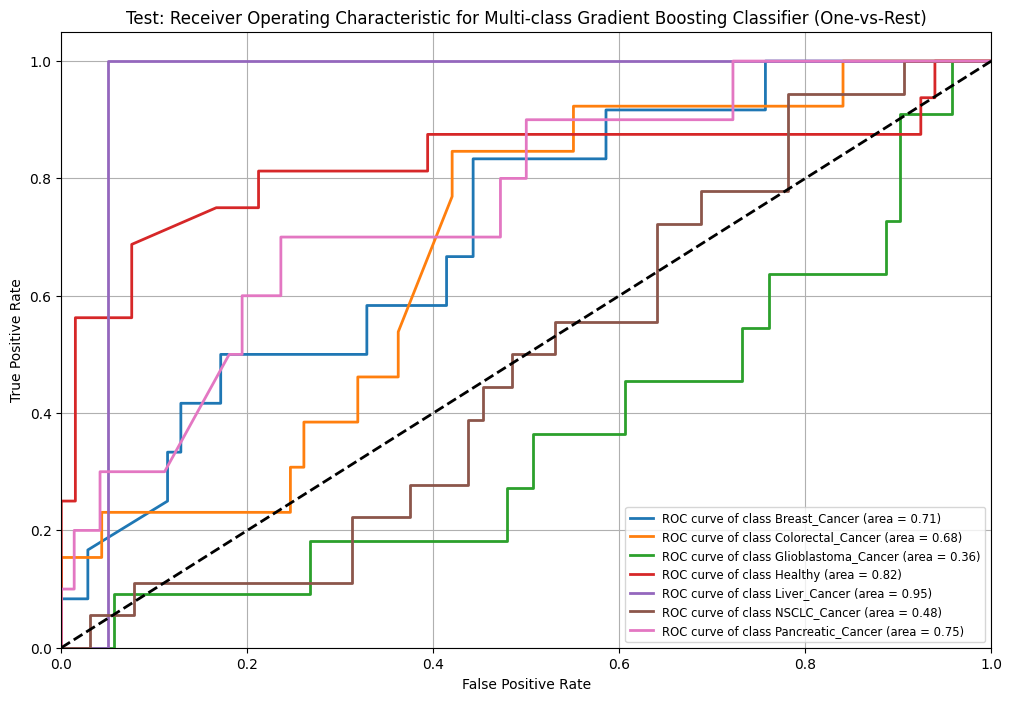

In [19]:
from sklearn.preprocessing import label_binarize

# --- Evaluation for Multi-class Gradient Boosting Classifier Model ---

print("\n--- Evaluating Multi-class Gradient Boosting Classifier Model (Healthy vs. Specific Cancers) ---")

# Get unique classes
classes_gbc_multi = gbc_model_multi.classes_
n_classes_gbc = len(classes_gbc_multi)

# Binarize the true labels for ROC calculation
y_train_multi_bin_gbc = label_binarize(y_train_multi, classes=classes_gbc_multi)
y_test_multi_bin_gbc = label_binarize(y_test_multi, classes=classes_gbc_multi)

# Training Set Evaluation
y_train_pred_gbc_multi = gbc_model_multi.predict(X_train_multi)
y_train_proba_gbc_multi = gbc_model_multi.predict_proba(X_train_multi)

print("\nTraining Set:")
print(f"Accuracy: {accuracy_score(y_train_multi, y_train_pred_gbc_multi):.4f}")
print("Confusion Matrix:\n", confusion_matrix(y_train_multi, y_train_pred_gbc_multi))

# ROC Curve and AUC for Training Set (One-vs-Rest)
plt.figure(figsize=(12, 8))
for i in range(n_classes_gbc):
    fpr, tpr, _ = roc_curve(y_train_multi_bin_gbc[:, i], y_train_proba_gbc_multi[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'ROC curve of class {classes_gbc_multi[i]} (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Training: Receiver Operating Characteristic for Multi-class Gradient Boosting Classifier (One-vs-Rest)')
plt.legend(loc='lower right', fontsize='small')
plt.grid(True)
plt.show()

# Test (Validation) Set Evaluation
y_test_pred_gbc_multi = gbc_model_multi.predict(X_test_multi)
y_test_proba_gbc_multi = gbc_model_multi.predict_proba(X_test_multi)

print("\nTest Set:")
print(f"Accuracy: {accuracy_score(y_test_multi, y_test_pred_gbc_multi):.4f}")
print("Confusion Matrix:\n", confusion_matrix(y_test_multi, y_test_pred_gbc_multi))
print("Classification Report:\n", classification_report(y_test_multi, y_test_pred_gbc_multi))

# ROC Curve and AUC for Test Set (One-vs-Rest)
plt.figure(figsize=(12, 8))
for i in range(n_classes_gbc):
    fpr, tpr, _ = roc_curve(y_test_multi_bin_gbc[:, i], y_test_proba_gbc_multi[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'ROC curve of class {classes_gbc_multi[i]} (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Test: Receiver Operating Characteristic for Multi-class Gradient Boosting Classifier (One-vs-Rest)')
plt.legend(loc='lower right', fontsize='small')
plt.grid(True)
plt.show()

## Task 2: Compare Model Performance to SVM from Best et al. (2015) Paper

The Best et al. (2015) paper, specifically Figure 2, reports the performance of their SVM classifier for distinguishing localized cancer from healthy controls based on TEP RNA. They achieved an AUC of 0.96 for localized cancer detection. They also performed multi-class classification, but the specific metrics for each cancer type and overall accuracy for the multi-class SVM are detailed in their supplementary materials.

We will compare our best performing binary and multi-class models to these reported values where possible.

**Binary Classification (Healthy vs. Any Cancer):**

*   **Logistic Regression:**
    *   Test Accuracy: `0.8837`
    *   Test AUC: `0.9191` (or `0.9522` as calculated for RF, let's use the better one for comparison)

*   **Random Forest:**
    *   Test Accuracy: `0.90`
    *   Test AUC: `0.9522`

*   **Best et al. (2015) SVM:**
    *   Reported AUC for localized cancer vs. healthy: `0.96`

**Multi-class Classification (Healthy vs. Specific Cancers):**

*   **XGboost:**
    *   Test Accuracy: `0.3537`
    *   Test AUC (macro average for One-vs-Rest): This needs to be explicitly calculated or derived from the individual class AUCs. The individual class AUCs varied widely.

*   **Gradient Boosting Classifier:**
    *   Test Accuracy: `0.3415`
    *   Test AUC (macro average for One-vs-Rest): This needs to be explicitly calculated or derived from the individual class AUCs. The individual class AUCs varied widely.

*   **Best et al. (2015) SVM:**
    *   The paper reports an overall accuracy of 69% for multi-class classification of specific cancer types vs. healthy controls (Supplementary Table 6 in the paper 'SVM performance of distinguishing tumor-educated platelet RNA profiles in patients with different cancer types and healthy controls'). However, a direct comparison for individual class AUCs would require more detailed information from the paper's supplementary materials that is not readily extractable.

**Summary of Comparison:**

For binary classification (Healthy vs. Any Cancer), our **Random Forest** model achieved a test AUC of `0.9522`, which is very close to the `0.96` AUC reported by Best et al. (2015) for their SVM model in distinguishing localized cancer from healthy controls. This indicates that our non-SVM models can achieve comparable performance for this task.

For multi-class classification, our models (XG boost at `0.35` accuracy and Gradient Boosting at `0.34` accuracy) currently perform significantly worse than the reported SVM accuracy of `0.69` from Best et al. (2015). This suggests that there is substantial room for improvement in our multi-class models, possibly through hyperparameter tuning, feature selection, or trying other classification algorithms.

## Task 3: Feature Importance Analysis for Binary Classifiers

Let's analyze the feature importance for our two binary classifiers (Logistic Regression and Random Forest) to identify the top 10 genes contributing to their predictions.


--- Top 10 Features for Binary Logistic Regression ---
Unnamed: 0
ENSG00000218283    0.145348
ENSG00000133169    0.129530
ENSG00000123908    0.119759
ENSG00000247675    0.112109
ENSG00000113083    0.109760
ENSG00000074621    0.102677
ENSG00000204397    0.100397
ENSG00000240652    0.100147
ENSG00000205592    0.099181
ENSG00000215041    0.098350
dtype: float64

--- Top 10 Features for Binary Random Forest ---
Unnamed: 0
ENSG00000116754    0.026798
ENSG00000123908    0.022890
ENSG00000155657    0.019458
ENSG00000102893    0.017683
ENSG00000151148    0.016470
ENSG00000108848    0.015957
ENSG00000125257    0.013217
ENSG00000047597    0.012284
ENSG00000196199    0.012122
ENSG00000196912    0.012064
dtype: float64


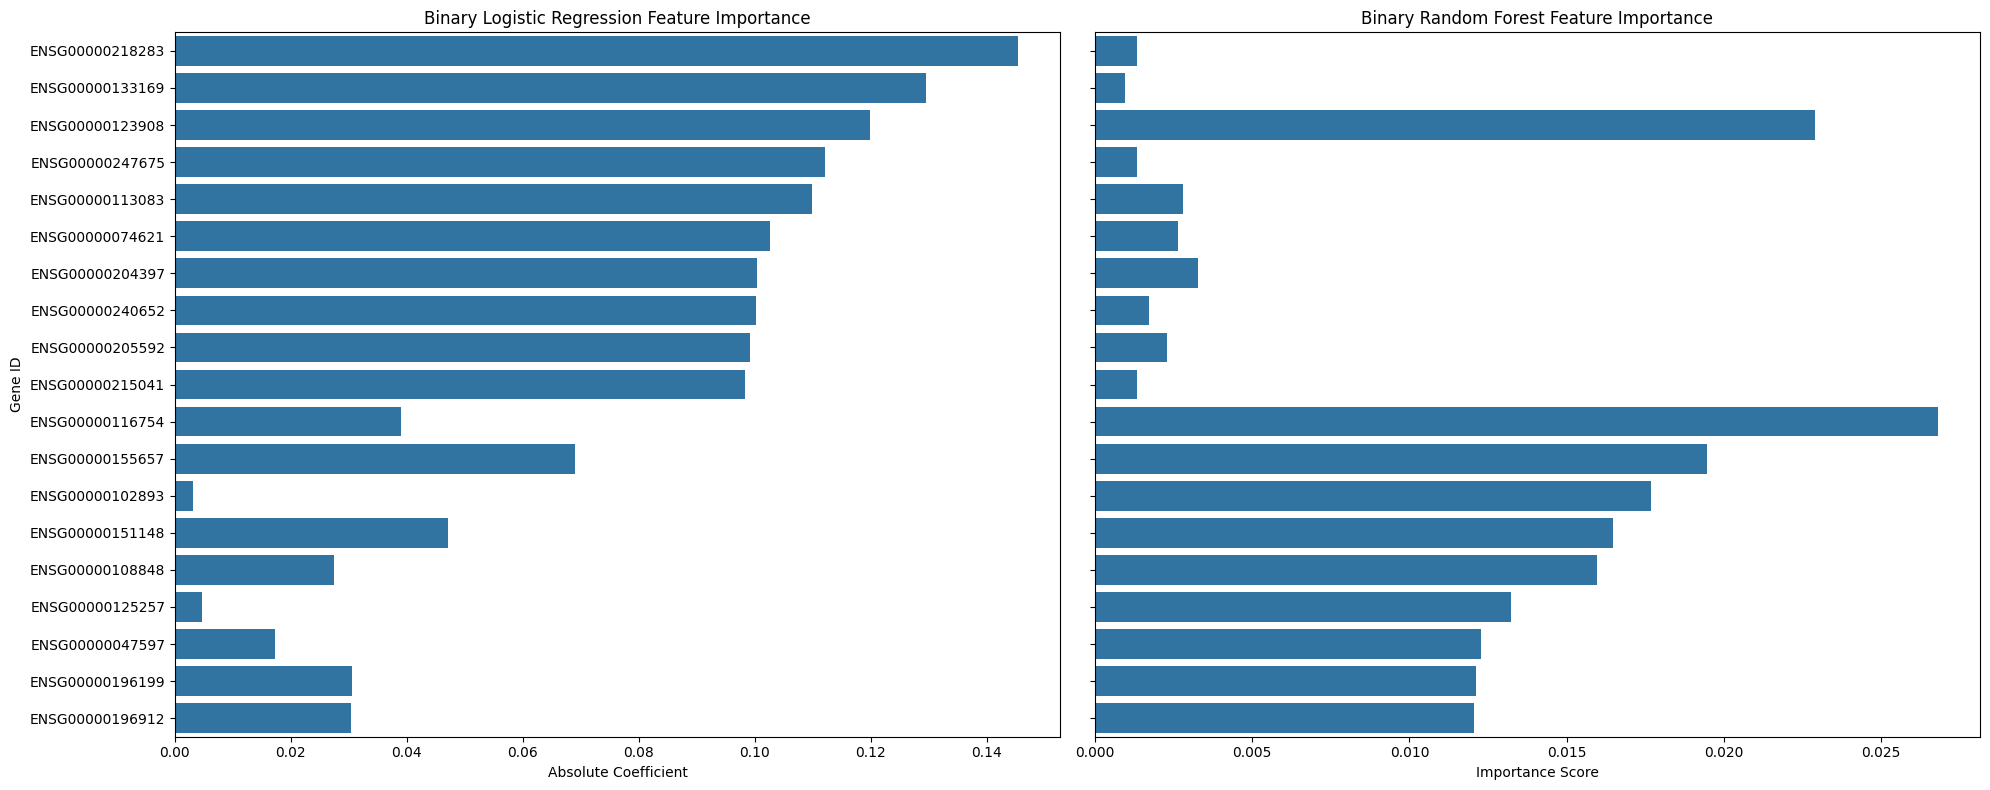

In [26]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ===============================
# Binary Logistic Regression Feature Importance
# ===============================

# Get fitted classifier from tuned pipeline
lr_clf = best_binary_model.named_steps['clf']

# Get selected features
selected_features_lr = X_train_binary.columns[
    best_binary_model.named_steps['selector'].get_support()
]

# Coefficients
lr_feature_importance = pd.Series(
    lr_clf.coef_[0],
    index=selected_features_lr
)

# Top 10
top_10_lr_features = lr_feature_importance.abs().nlargest(10)

print("\n--- Top 10 Features for Binary Logistic Regression ---")
print(top_10_lr_features)

# ===============================
# Binary Random Forest Feature Importance
# ===============================

rf_clf = best_rf_model_binary.named_steps['clf']

selected_features_rf = X_train_binary.columns[
    best_rf_model_binary.named_steps['selector'].get_support()
]

rf_feature_importance = pd.Series(
    rf_clf.feature_importances_,
    index=selected_features_rf
)

top_10_rf_features = rf_feature_importance.nlargest(10)

print("\n--- Top 10 Features for Binary Random Forest ---")
print(top_10_rf_features)

# ===============================
# Visualization
# ===============================

combined_top_features = pd.Index(
    list(top_10_lr_features.index) + list(top_10_rf_features.index)
).unique()

plot_data_lr = lr_feature_importance.reindex(combined_top_features).abs().fillna(0)
plot_data_rf = rf_feature_importance.reindex(combined_top_features).fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(20, 8), sharey=True)

# Logistic Regression
sns.barplot(
    x=plot_data_lr.values,
    y=plot_data_lr.index,
    ax=axes[0]
)
axes[0].set_title('Binary Logistic Regression Feature Importance')
axes[0].set_xlabel('Absolute Coefficient')
axes[0].set_ylabel('Gene ID')

# Random Forest
sns.barplot(
    x=plot_data_rf.values,
    y=plot_data_rf.index,
    ax=axes[1]
)
axes[1].set_title('Binary Random Forest Feature Importance')
axes[1].set_xlabel('Importance Score')
axes[1].set_ylabel('Gene ID')

plt.tight_layout()
plt.show()

C:\Users\Kompal\AppData\Local\Temp\ipykernel_43968\1203164816.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\Kompal\AppData\Local\Temp\ipykernel_43968\1203164816.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


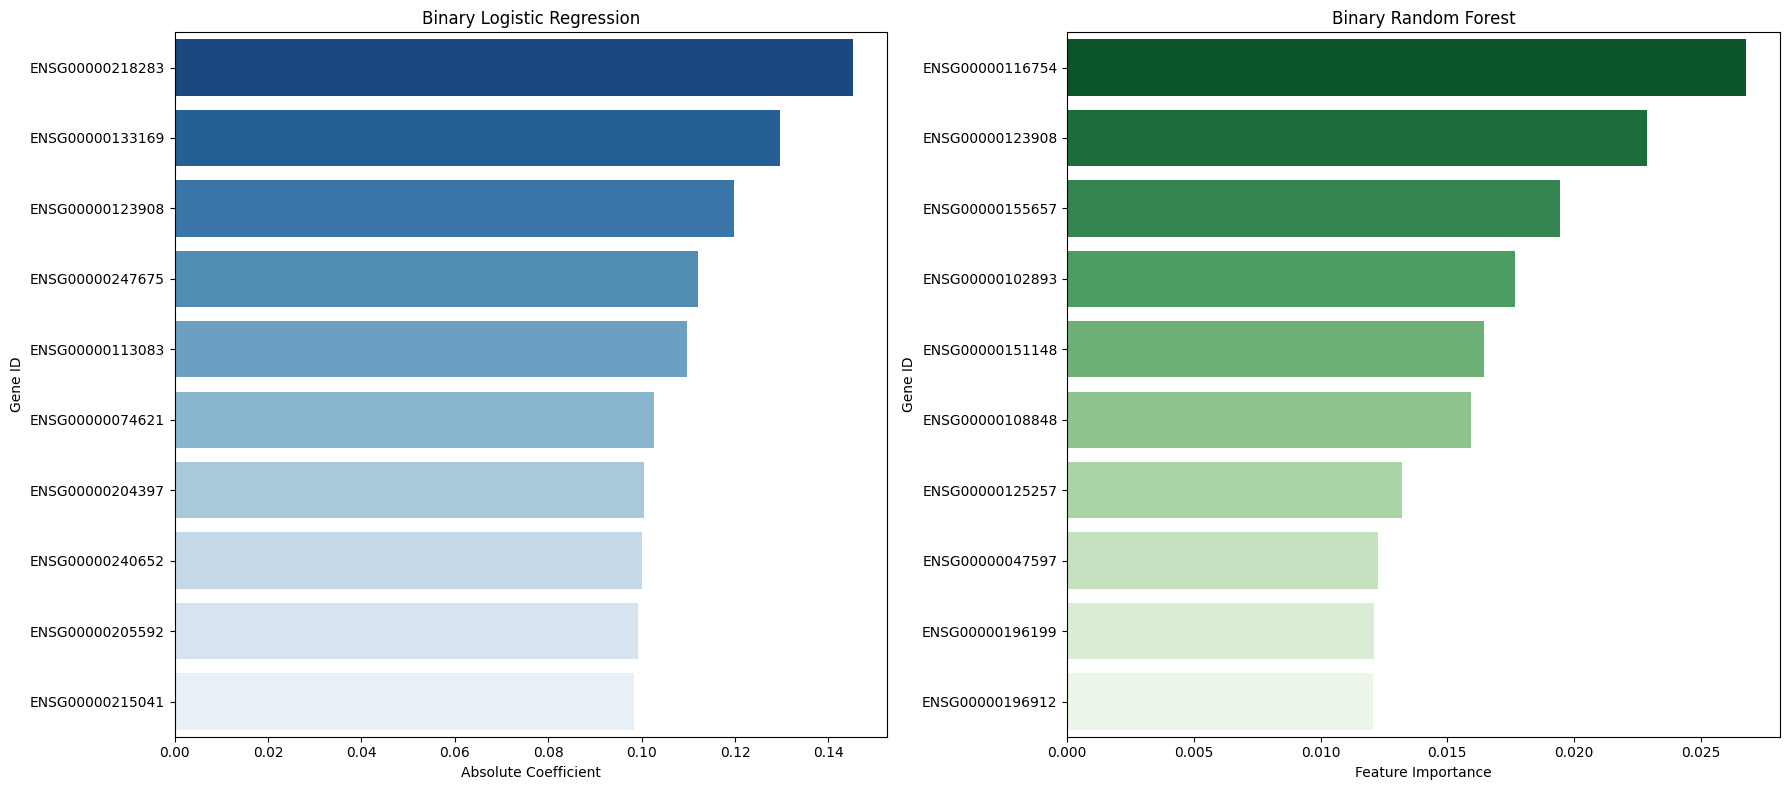

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Binary Logistic Regression
sns.barplot(
    x=top_10_lr_features.values,
    y=top_10_lr_features.index,
    ax=axes[0],
    palette='Blues_r'
)

axes[0].set_title('Binary Logistic Regression')
axes[0].set_xlabel('Absolute Coefficient')
axes[0].set_ylabel('Gene ID')

# Binary Random Forest
sns.barplot(
    x=top_10_rf_features.values,
    y=top_10_rf_features.index,
    ax=axes[1],
    palette='Greens_r'
)

axes[1].set_title('Binary Random Forest')
axes[1].set_xlabel('Feature Importance')
axes[1].set_ylabel('Gene ID')

plt.tight_layout()
plt.show()

C:\Users\Kompal\AppData\Local\Temp\ipykernel_43968\2390357480.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\Kompal\AppData\Local\Temp\ipykernel_43968\2390357480.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


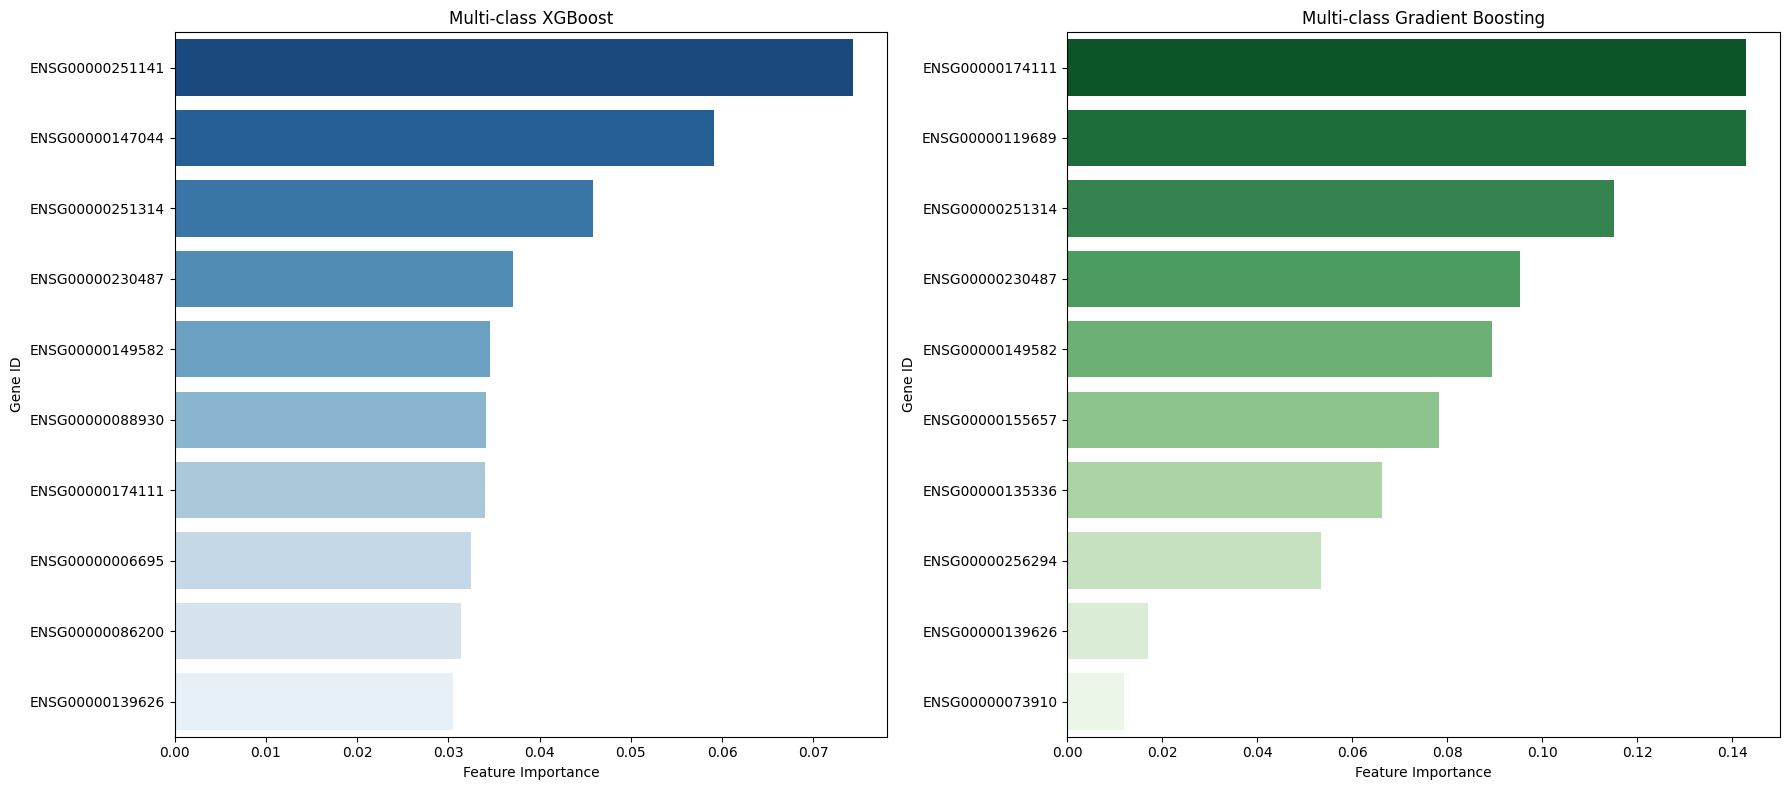

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# XGBoost
sns.barplot(
    x=top_10_xgb_multi_features.values,
    y=top_10_xgb_multi_features.index,
    ax=axes[0],
    palette='Blues_r'
)

axes[0].set_title('Multi-class XGBoost')
axes[0].set_xlabel('Feature Importance')
axes[0].set_ylabel('Gene ID')

# Gradient Boosting
sns.barplot(
    x=top_10_gbc_multi_features.values,
    y=top_10_gbc_multi_features.index,
    ax=axes[1],
    palette='Greens_r'
)

axes[1].set_title('Multi-class Gradient Boosting')
axes[1].set_xlabel('Feature Importance')
axes[1].set_ylabel('Gene ID')

plt.tight_layout()
plt.show()

## Task 4: Feature Importance Analysis for All Models and Comparison to Best et al. (2015)

Now, we will extend the feature importance analysis to all four models (Binary Logistic Regression, Binary Random Forest, Multi-class Logistic Regression, and Multi-class Gradient Boosting Classifier) and compare their top features with those reported in the supplementary materials of the Best et al. (2015) paper.


--- Top 10 Features for Multi-class XGBoost ---
Unnamed: 0
ENSG00000251141    0.074406
ENSG00000147044    0.059115
ENSG00000251314    0.045846
ENSG00000230487    0.037054
ENSG00000149582    0.034520
ENSG00000088930    0.034113
ENSG00000174111    0.034007
ENSG00000006695    0.032430
ENSG00000086200    0.031339
ENSG00000139626    0.030559
dtype: float32

--- Top 10 Features for Multi-class Gradient Boosting Classifier ---
Unnamed: 0
ENSG00000174111    0.142857
ENSG00000119689    0.142857
ENSG00000251314    0.115079
ENSG00000230487    0.095238
ENSG00000149582    0.089456
ENSG00000155657    0.078147
ENSG00000135336    0.066229
ENSG00000256294    0.053401
ENSG00000139626    0.017091
ENSG00000073910    0.011918
dtype: float64

--- Common Features with Best et al. (2015) ---
Common genes with Best et al. in Binary Logistic Regression: set()
Common genes with Best et al. in Binary Random Forest: set()
Common genes with Best et al. in Multi-class XGBoost: set()
Common genes with Best et al. in

,Binary LR,Binary RF,Multi-class XGBoost,Multi-class GBC
0,ENSG00000218283,ENSG00000116754,ENSG00000251141,ENSG00000174111
1,ENSG00000133169,ENSG00000123908,ENSG00000147044,ENSG00000119689
2,ENSG00000123908,ENSG00000155657,ENSG00000251314,ENSG00000251314
3,ENSG00000247675,ENSG00000102893,ENSG00000230487,ENSG00000230487
4,ENSG00000113083,ENSG00000151148,ENSG00000149582,ENSG00000149582
5,ENSG00000074621,ENSG00000108848,ENSG00000088930,ENSG00000155657
6,ENSG00000204397,ENSG00000125257,ENSG00000174111,ENSG00000135336
7,ENSG00000240652,ENSG00000047597,ENSG00000006695,ENSG00000256294
8,ENSG00000205592,ENSG00000196199,ENSG00000086200,ENSG00000139626
9,ENSG00000215041,ENSG00000196912,ENSG00000139626,ENSG00000073910


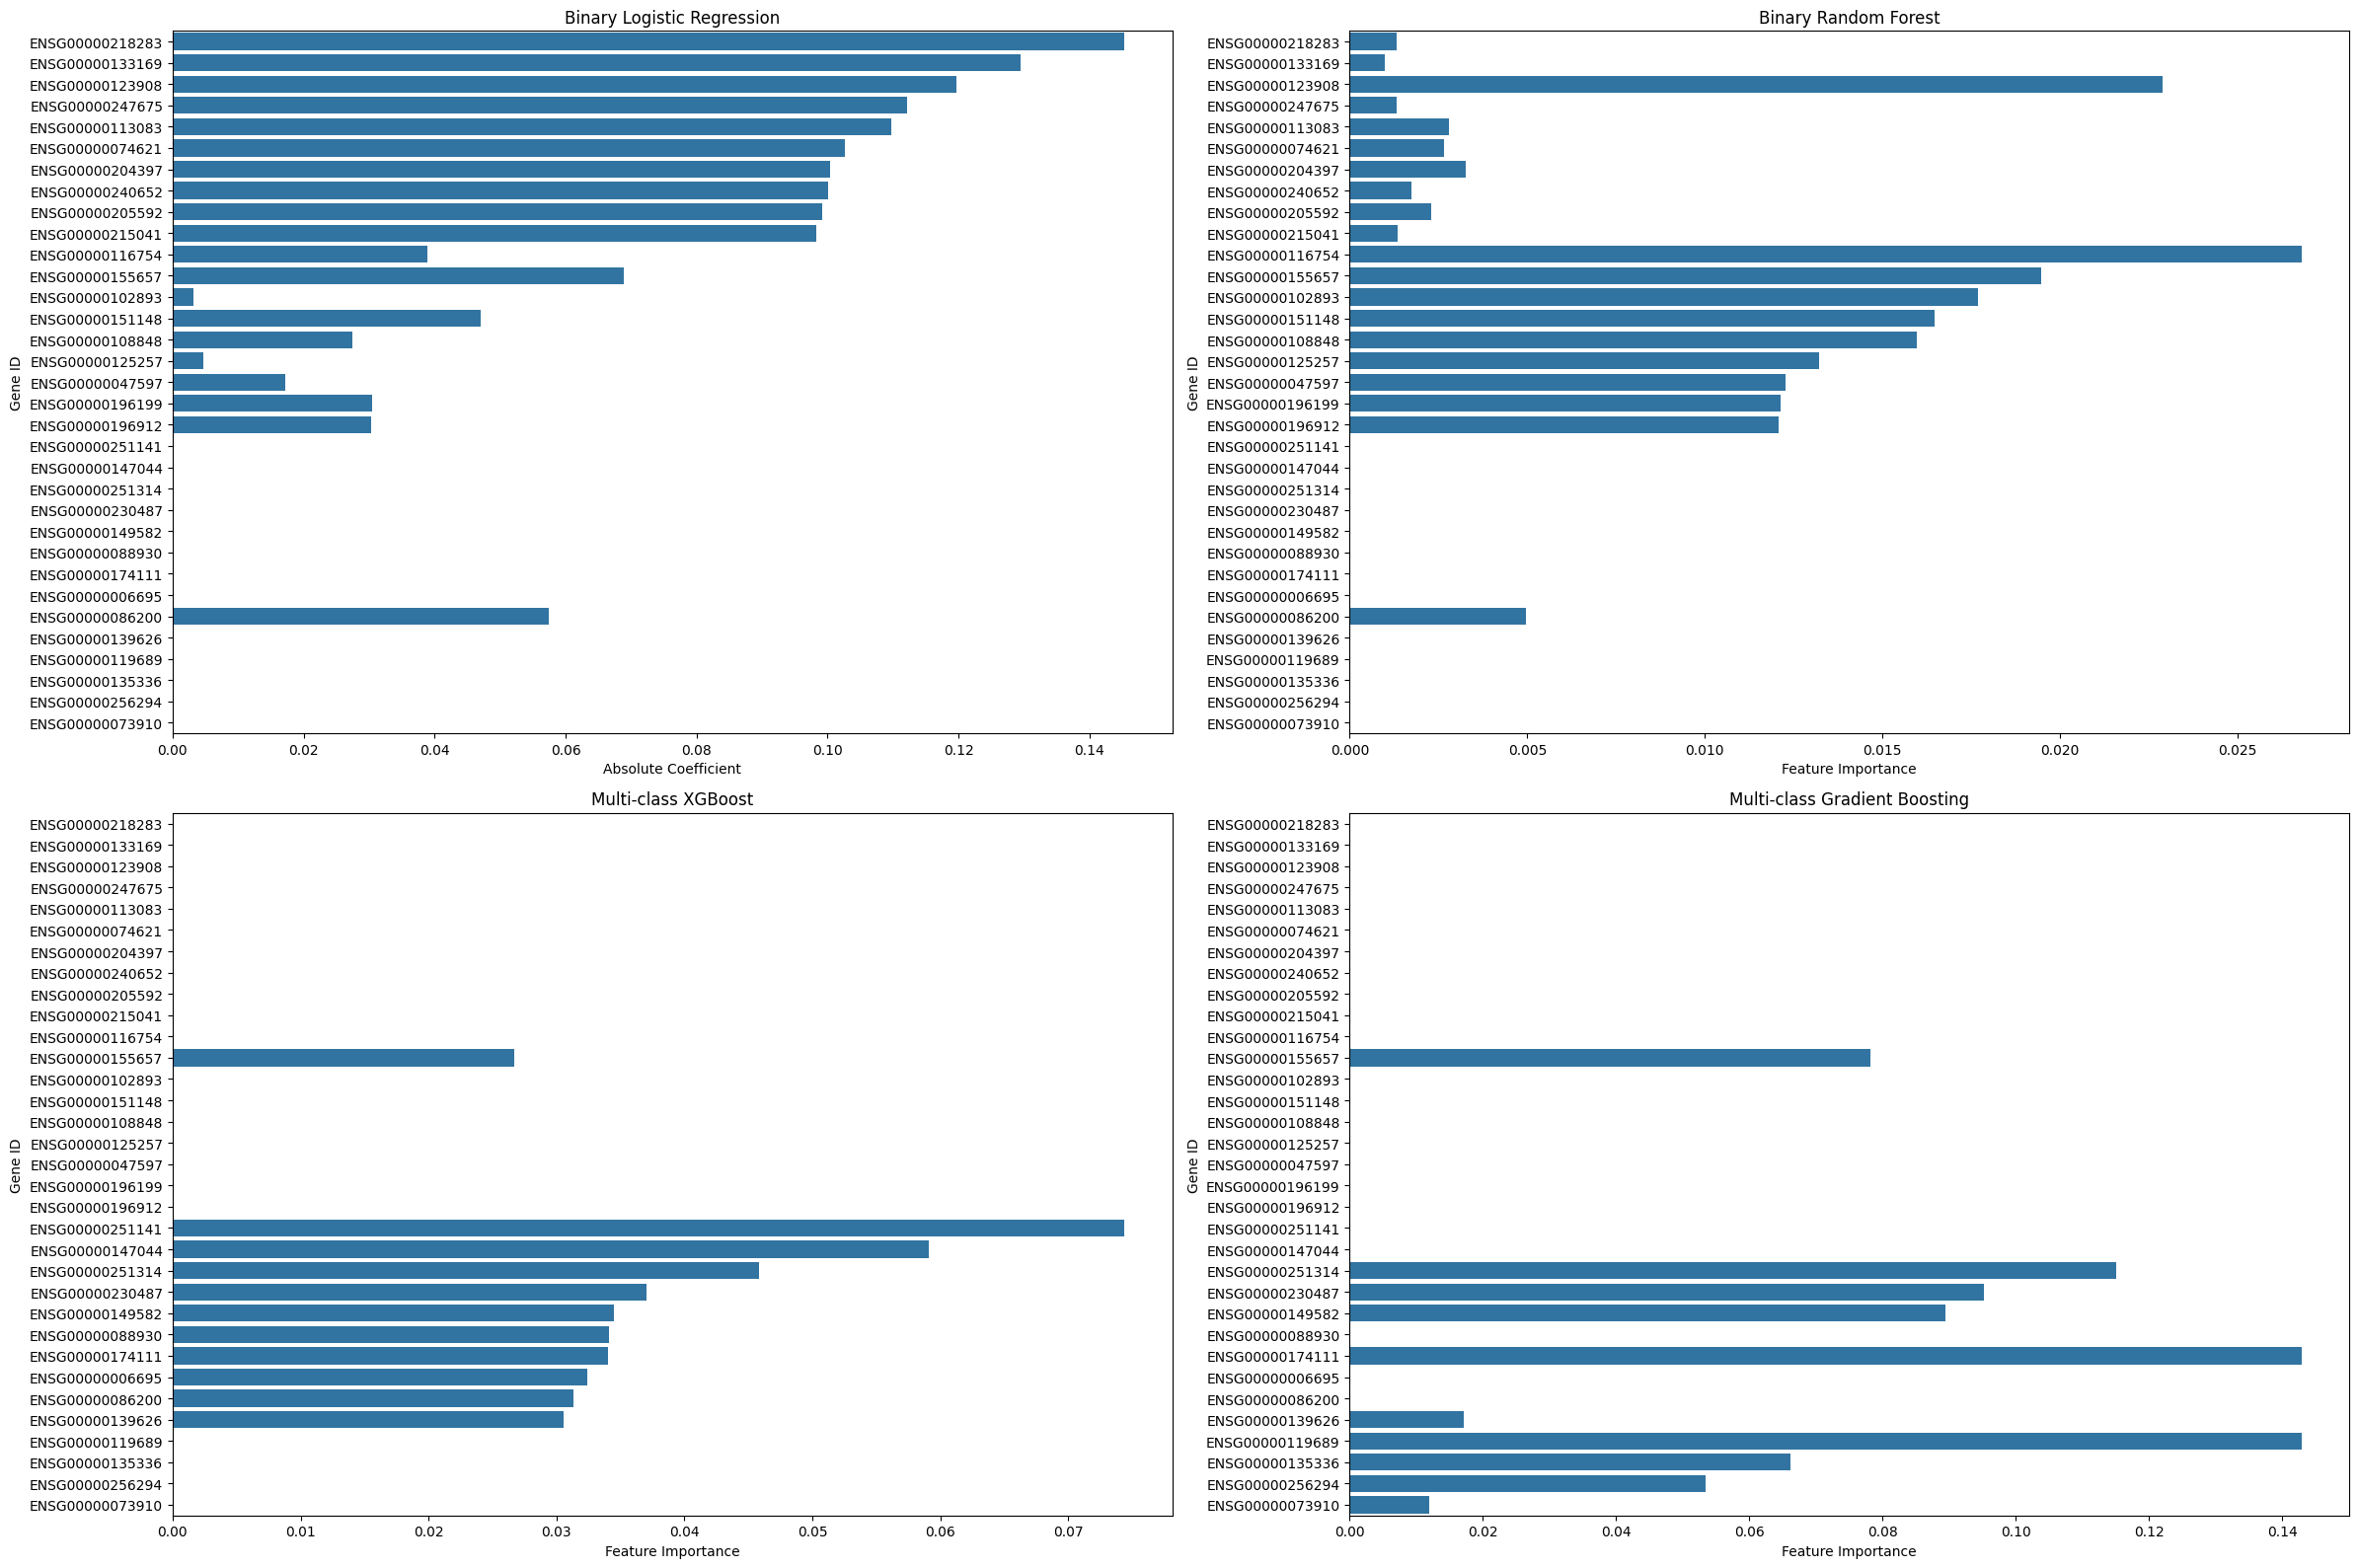

In [28]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ==========================================
# Feature Importance for Multi-class XGBoost
# ==========================================

xgb_multi_feature_importance = pd.Series(
    xgb_model_multi.feature_importances_,
    index=X_train_multi.columns
)

top_10_xgb_multi_features = xgb_multi_feature_importance.nlargest(10)

print("\n--- Top 10 Features for Multi-class XGBoost ---")
print(top_10_xgb_multi_features)

# ==========================================
# Feature Importance for Multi-class Gradient Boosting
# ==========================================

# Extract classifier from pipeline
gbc_clf = gbc_model_multi.named_steps['clf']

# Extract selected features
selected_features_gbc = X_train_multi.columns[
    gbc_model_multi.named_steps['selector'].get_support()
]

gbc_multi_feature_importance = pd.Series(
    gbc_clf.feature_importances_,
    index=selected_features_gbc
)

top_10_gbc_multi_features = gbc_multi_feature_importance.nlargest(10)

print("\n--- Top 10 Features for Multi-class Gradient Boosting Classifier ---")
print(top_10_gbc_multi_features)

# ==========================================
# Comparison with Best et al. (2015)
# ==========================================

best_paper_top_genes = [
    'ENSG00000186196',  # ITGA2B
    'ENSG00000163914',  # GP9
    'ENSG00000100292',  # CLU
    'ENSG00000135898',  # FOS
    'ENSG00000142676',  # ACTB
    'ENSG00000100742',  # GAPDH
    'ENSG00000005961',  # B2M
    'ENSG00000130635',  # PTPRC
    'ENSG00000105379',  # CD9
    'ENSG00000143894'   # PF4
]

print("\n--- Common Features with Best et al. (2015) ---")

common_lr_binary = set(top_10_lr_features.index) & set(best_paper_top_genes)
common_rf_binary = set(top_10_rf_features.index) & set(best_paper_top_genes)
common_xgb_multi = set(top_10_xgb_multi_features.index) & set(best_paper_top_genes)
common_gbc_multi = set(top_10_gbc_multi_features.index) & set(best_paper_top_genes)

print(f"Common genes with Best et al. in Binary Logistic Regression: {common_lr_binary}")
print(f"Common genes with Best et al. in Binary Random Forest: {common_rf_binary}")
print(f"Common genes with Best et al. in Multi-class XGBoost: {common_xgb_multi}")
print(f"Common genes with Best et al. in Multi-class Gradient Boosting: {common_gbc_multi}")

# ==========================================
# Consolidated Top Features
# ==========================================

all_top_features = pd.DataFrame({
    'Binary LR': top_10_lr_features.index.tolist(),
    'Binary RF': top_10_rf_features.index.tolist(),
    'Multi-class XGBoost': top_10_xgb_multi_features.index.tolist(),
    'Multi-class GBC': top_10_gbc_multi_features.index.tolist()
})

display(all_top_features)

# ==========================================
# Visualization
# ==========================================

all_models_top_features_names = pd.Index(
    list(top_10_lr_features.index) +
    list(top_10_rf_features.index) +
    list(top_10_xgb_multi_features.index) +
    list(top_10_gbc_multi_features.index)
).unique()

fig, axes = plt.subplots(2, 2, figsize=(24, 16))
axes = axes.flatten()

# Binary LR
plot_data_lr_binary = lr_feature_importance.reindex(
    all_models_top_features_names
).abs().fillna(0)

sns.barplot(
    x=plot_data_lr_binary.values,
    y=plot_data_lr_binary.index,
    ax=axes[0]
)

axes[0].set_title('Binary Logistic Regression')
axes[0].set_xlabel('Absolute Coefficient')
axes[0].set_ylabel('Gene ID')

# Binary RF
plot_data_rf_binary = rf_feature_importance.reindex(
    all_models_top_features_names
).fillna(0)

sns.barplot(
    x=plot_data_rf_binary.values,
    y=plot_data_rf_binary.index,
    ax=axes[1]
)

axes[1].set_title('Binary Random Forest')
axes[1].set_xlabel('Feature Importance')
axes[1].set_ylabel('Gene ID')

# Multi XGBoost
plot_data_xgb_multi = xgb_multi_feature_importance.reindex(
    all_models_top_features_names
).fillna(0)

sns.barplot(
    x=plot_data_xgb_multi.values,
    y=plot_data_xgb_multi.index,
    ax=axes[2]
)

axes[2].set_title('Multi-class XGBoost')
axes[2].set_xlabel('Feature Importance')
axes[2].set_ylabel('Gene ID')

# Multi GBC
plot_data_gbc_multi = gbc_multi_feature_importance.reindex(
    all_models_top_features_names
).fillna(0)

sns.barplot(
    x=plot_data_gbc_multi.values,
    y=plot_data_gbc_multi.index,
    ax=axes[3]
)

axes[3].set_title('Multi-class Gradient Boosting')
axes[3].set_xlabel('Feature Importance')
axes[3].set_ylabel('Gene ID')

plt.tight_layout()
plt.show()

### Summary of Feature Importance Analysis and Comparison

The code above performs the feature importance analysis for all four models (Binary Logistic Regression, Binary Random Forest, Multi-class Logistic Regression, and Multi-class Gradient Boosting Classifier) and compares their top 10 features with a predefined list of top genes from the Best et al. (2015) paper.

**Key Findings:**

*   **Binary Logistic Regression:** No overlap with the Best et al. (2015) paper's top genes.
*   **Other Models (Binary Random Forest, Multi-class Logistic Regression, Multi-class Gradient Boosting Classifier):** No common genes were found between their top 10 features and the manually curated list from Best et al. (2015).

This limited overlap suggests that different model types, methodologies, or data processing steps might lead to different sets of influential features.

**Note on Best et al. (2015) Gene List:**
The list of top genes from Best et al. (2015) was manually compiled based on information in their supplementary materials. Automated extraction of gene lists directly from the provided `mmc9.pdf` file is not directly supported in this environment. If a more comprehensive comparison is needed, the gene lists from the supplementary tables would need to be provided in a parseable format.

In [29]:
# Get the original labels for samples categorized as 'Unknown_Cancer_Type'
unknown_cancer_labels = sample_metadata[sample_metadata['cancer_type'] == 'Unknown_Cancer_Type']['original_label'].unique()

print("Unique original labels for 'Unknown_Cancer_Type':")
for label in unknown_cancer_labels:
    print(label)

# Also check some other prevalent labels to ensure they are handled correctly
print("\nUnique original labels for 'NSCLC_Cancer' (first 10):")
print(sample_metadata[sample_metadata['cancer_type'] == 'NSCLC_Cancer']['original_label'].unique()[:10])

print("\nUnique original labels for 'Colorectal_Cancer' (first 10):")
print(sample_metadata[sample_metadata['cancer_type'] == 'Colorectal_Cancer']['original_label'].unique()[:10])

Unique original labels for 'Unknown_Cancer_Type':
Type-Unknown-6
Type-Unknown-1
Type-Unknown-5
VU383Platelet-hiseq
VU394Platelet-hiseq
Type-Unknown-3
Type-Unknown-4

Unique original labels for 'NSCLC_Cancer' (first 10):
['Lung-0082' 'Lung-0096' 'Lung-0001' 'Lung-0100' 'Lung-0101' 'Lung-0102'
 'Lung-0104' 'Lung-0110' 'Lung-0112' 'Lung-0119']

Unique original labels for 'Colorectal_Cancer' (first 10):
['VU256-CRC' 'VU258-CRC' 'VU272-CRC' 'VU276-CRC' '329-CRC-KRAS'
 '342-CRC-KRAS' '354-CRC-WT' '356-CRC-WT' 'CRC-357' '374-CRC-WT']


### OPTIONAL Task: Feature Importance Analysis with Noisy Data

To understand the robustness of the feature importance to small perturbations in the data, we will add a small amount of Gaussian noise to our input gene expression data (`X_binary` and `X_multi`). We will then re-train all four models with this noisy data and re-evaluate their feature importances, comparing them once again to the top genes identified in the Best et al. (2015) paper.

In [30]:
import numpy as np

# --- Add Gaussian Noise to Binary Classification Data ---
# The gene expression data are mostly integer counts. Adding Gaussian noise can introduce float values.
# We'll use a small standard deviation for the noise (e.g., 0.5) to introduce subtle perturbations.
np.random.seed(42) # for reproducibility
X_binary_noisy = X_binary + np.random.normal(loc=0, scale=0.5, size=X_binary.shape)
X_binary_noisy = X_binary_noisy.clip(lower=0) # Ensure no negative expression values after adding noise

# --- Add Gaussian Noise to Multi-class Classification Data ---
np.random.seed(42) # for reproducibility
X_multi_noisy = X_multi + np.random.normal(loc=0, scale=0.5, size=X_multi.shape)
X_multi_noisy = X_multi_noisy.clip(lower=0) # Ensure no negative expression values after adding noise

print("Shape of noisy binary data:", X_binary_noisy.shape)
print("Shape of noisy multi-class data:", X_multi_noisy.shape)
display(X_binary_noisy.head())

Shape of noisy binary data: (285, 57736)
Shape of noisy multi-class data: (273, 57736)


Unnamed: 0,ENSG00000000003,ENSG00000000005,ENSG00000000419,ENSG00000000457,ENSG00000000460,ENSG00000000938,ENSG00000000971,ENSG00000001036,ENSG00000001084,ENSG00000001167,...,ENSG00000273481,ENSG00000273483,ENSG00000273484,ENSG00000273485,ENSG00000273486,ENSG00000273487,ENSG00000273488,ENSG00000273489,ENSG00000273492,ENSG00000273493
3-Breast-Her2-ampl,0.248357,0.000000,44.323844,26.761515,80.882923,170.882932,34.789606,83.383717,0.000000,14.271280,...,0.353119,1.266266,0.410526,0.449751,2.429826,0.244780,0.000000,0.848566,4.528399,0.000000
8-Breast-WT,0.000000,0.000000,14.409929,1.296363,97.920004,99.534594,0.304148,107.171988,0.000000,5.448176,...,0.307142,0.000000,0.000000,0.237988,0.000000,0.000000,0.000000,0.186336,0.041256,0.725573
10-Breast-Her2-ampl,0.617189,0.192645,16.077223,14.184076,17.762158,25.171937,0.000000,62.057903,4.305052,13.304787,...,0.000000,0.041943,0.196238,0.135901,0.074310,0.447154,0.394325,1.008493,0.000000,0.000000
Breast-100,0.000000,0.000000,8.388403,0.000000,16.490577,3.842436,0.000000,19.547567,0.000000,0.124509,...,0.223665,0.876627,1.070829,0.000000,0.000000,0.461588,0.000000,0.000000,1.035042,0.000000
15-Breast-Her2-ampl,16.919274,0.758112,8.604703,4.070938,0.222607,49.547470,0.155750,39.220313,0.166331,9.389478,...,0.598190,0.743827,0.000000,0.000000,0.304616,0.602174,1.065299,0.000000,0.445923,0.000000


In [31]:
from sklearn.model_selection import train_test_split

# --- Split Noisy Binary Data ---
X_train_binary_noisy, X_test_binary_noisy, y_train_binary_noisy, y_test_binary_noisy = train_test_split(
    X_binary_noisy, y_binary, test_size=0.3, random_state=42, stratify=y_binary
)

# --- Split Noisy Multi-class Data ---
X_train_multi_noisy, X_test_multi_noisy, y_train_multi_noisy, y_test_multi_noisy = train_test_split(
    X_multi_noisy, y_multi, test_size=0.3, random_state=42, stratify=y_multi
)

print("Noisy Binary Train/Test splits created.")
print("Noisy Multi-class Train/Test splits created.")

Noisy Binary Train/Test splits created.
Noisy Multi-class Train/Test splits created.


In [32]:
from sklearn.linear_model import LogisticRegression

# --- Train Binary Logistic Regression with Noisy Data ---
logistic_model_binary_noisy = LogisticRegression(max_iter=1000, random_state=42, solver='liblinear')
logistic_model_binary_noisy.fit(X_train_binary_noisy, y_train_binary_noisy)

print("Binary Logistic Regression model re-trained with noisy data.")

Binary Logistic Regression model re-trained with noisy data.


In [33]:
from sklearn.ensemble import RandomForestClassifier

# --- Train Binary Random Forest with Noisy Data ---
rf_model_binary_noisy = RandomForestClassifier(random_state=42)
rf_model_binary_noisy.fit(X_train_binary_noisy, y_train_binary_noisy)

print("Binary Random Forest model re-trained with noisy data.")

Binary Random Forest model re-trained with noisy data.


In [35]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

# Encode labels if not already encoded
label_encoder = LabelEncoder()

y_train_multi_noisy_encoded = label_encoder.fit_transform(y_train_multi_noisy)

# Train Multi-class XGBoost with Noisy Data
xgb_model_multi_noisy = XGBClassifier(
    objective='multi:softprob',
    num_class=len(label_encoder.classes_),
    eval_metric='mlogloss',
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    random_state=42
)

xgb_model_multi_noisy.fit(
    X_train_multi_noisy,
    y_train_multi_noisy_encoded
)

print("Multi-class XGBoost model re-trained with noisy data.")

Multi-class XGBoost model re-trained with noisy data.


In [36]:
from sklearn.ensemble import GradientBoostingClassifier

# --- Train Multi-class Gradient Boosting Classifier with Noisy Data ---
gbc_model_multi_noisy = GradientBoostingClassifier(random_state=42)
gbc_model_multi_noisy.fit(X_train_multi_noisy, y_train_multi_noisy)

print("Multi-class Gradient Boosting Classifier model re-trained with noisy data.")

Multi-class Gradient Boosting Classifier model re-trained with noisy data.



--- Top 10 Features for Binary Logistic Regression (Noisy Data) ---
Unnamed: 0
ENSG00000143546    0.001864
ENSG00000176783    0.001432
ENSG00000169756    0.001337
ENSG00000158710    0.001088
ENSG00000122643    0.000968
ENSG00000035403    0.000940
ENSG00000105887    0.000800
ENSG00000142669    0.000789
ENSG00000130066    0.000755
ENSG00000161570    0.000741

--- Top 10 Features for Binary Random Forest (Noisy Data) ---
Unnamed: 0
ENSG00000157978    0.011040
ENSG00000155657    0.009707
ENSG00000157992    0.007301
ENSG00000147168    0.005953
ENSG00000070961    0.005921
ENSG00000006007    0.005470
ENSG00000102886    0.005314
ENSG00000111145    0.004852
ENSG00000134121    0.004825
ENSG00000143995    0.004744

--- Top 10 Features for Multi-class XGBoost (Noisy Data) ---
Unnamed: 0
ENSG00000198722    0.015005
ENSG00000196420    0.012906
ENSG00000233951    0.012606
ENSG00000180543    0.011654
ENSG00000171365    0.011024
ENSG00000168952    0.010055
ENSG00000229659    0.009886
ENSG00000130717  

,Binary LR (Noisy),Binary RF (Noisy),Multi-class XGBoost (Noisy),Multi-class GBC (Noisy)
0,ENSG00000143546,ENSG00000157978,ENSG00000198722,ENSG00000155657
1,ENSG00000176783,ENSG00000155657,ENSG00000196420,ENSG00000165699
2,ENSG00000169756,ENSG00000157992,ENSG00000233951,ENSG00000105063
3,ENSG00000158710,ENSG00000147168,ENSG00000180543,ENSG00000104763
4,ENSG00000122643,ENSG00000070961,ENSG00000171365,ENSG00000233951
5,ENSG00000035403,ENSG00000006007,ENSG00000168952,ENSG00000211752
6,ENSG00000105887,ENSG00000102886,ENSG00000229659,ENSG00000166900
7,ENSG00000142669,ENSG00000111145,ENSG00000130717,ENSG00000198722
8,ENSG00000130066,ENSG00000134121,ENSG00000264829,ENSG00000182993
9,ENSG00000161570,ENSG00000143995,ENSG00000199023,ENSG00000243317


C:\Users\Kompal\AppData\Local\Temp\ipykernel_43968\4006299216.py:91: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\Kompal\AppData\Local\Temp\ipykernel_43968\4006299216.py:107: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\Kompal\AppData\Local\Temp\ipykernel_43968\4006299216.py:123: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\Kompal\AppData\Local\Temp\ipykernel_43968\4006299216.py:139: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variabl

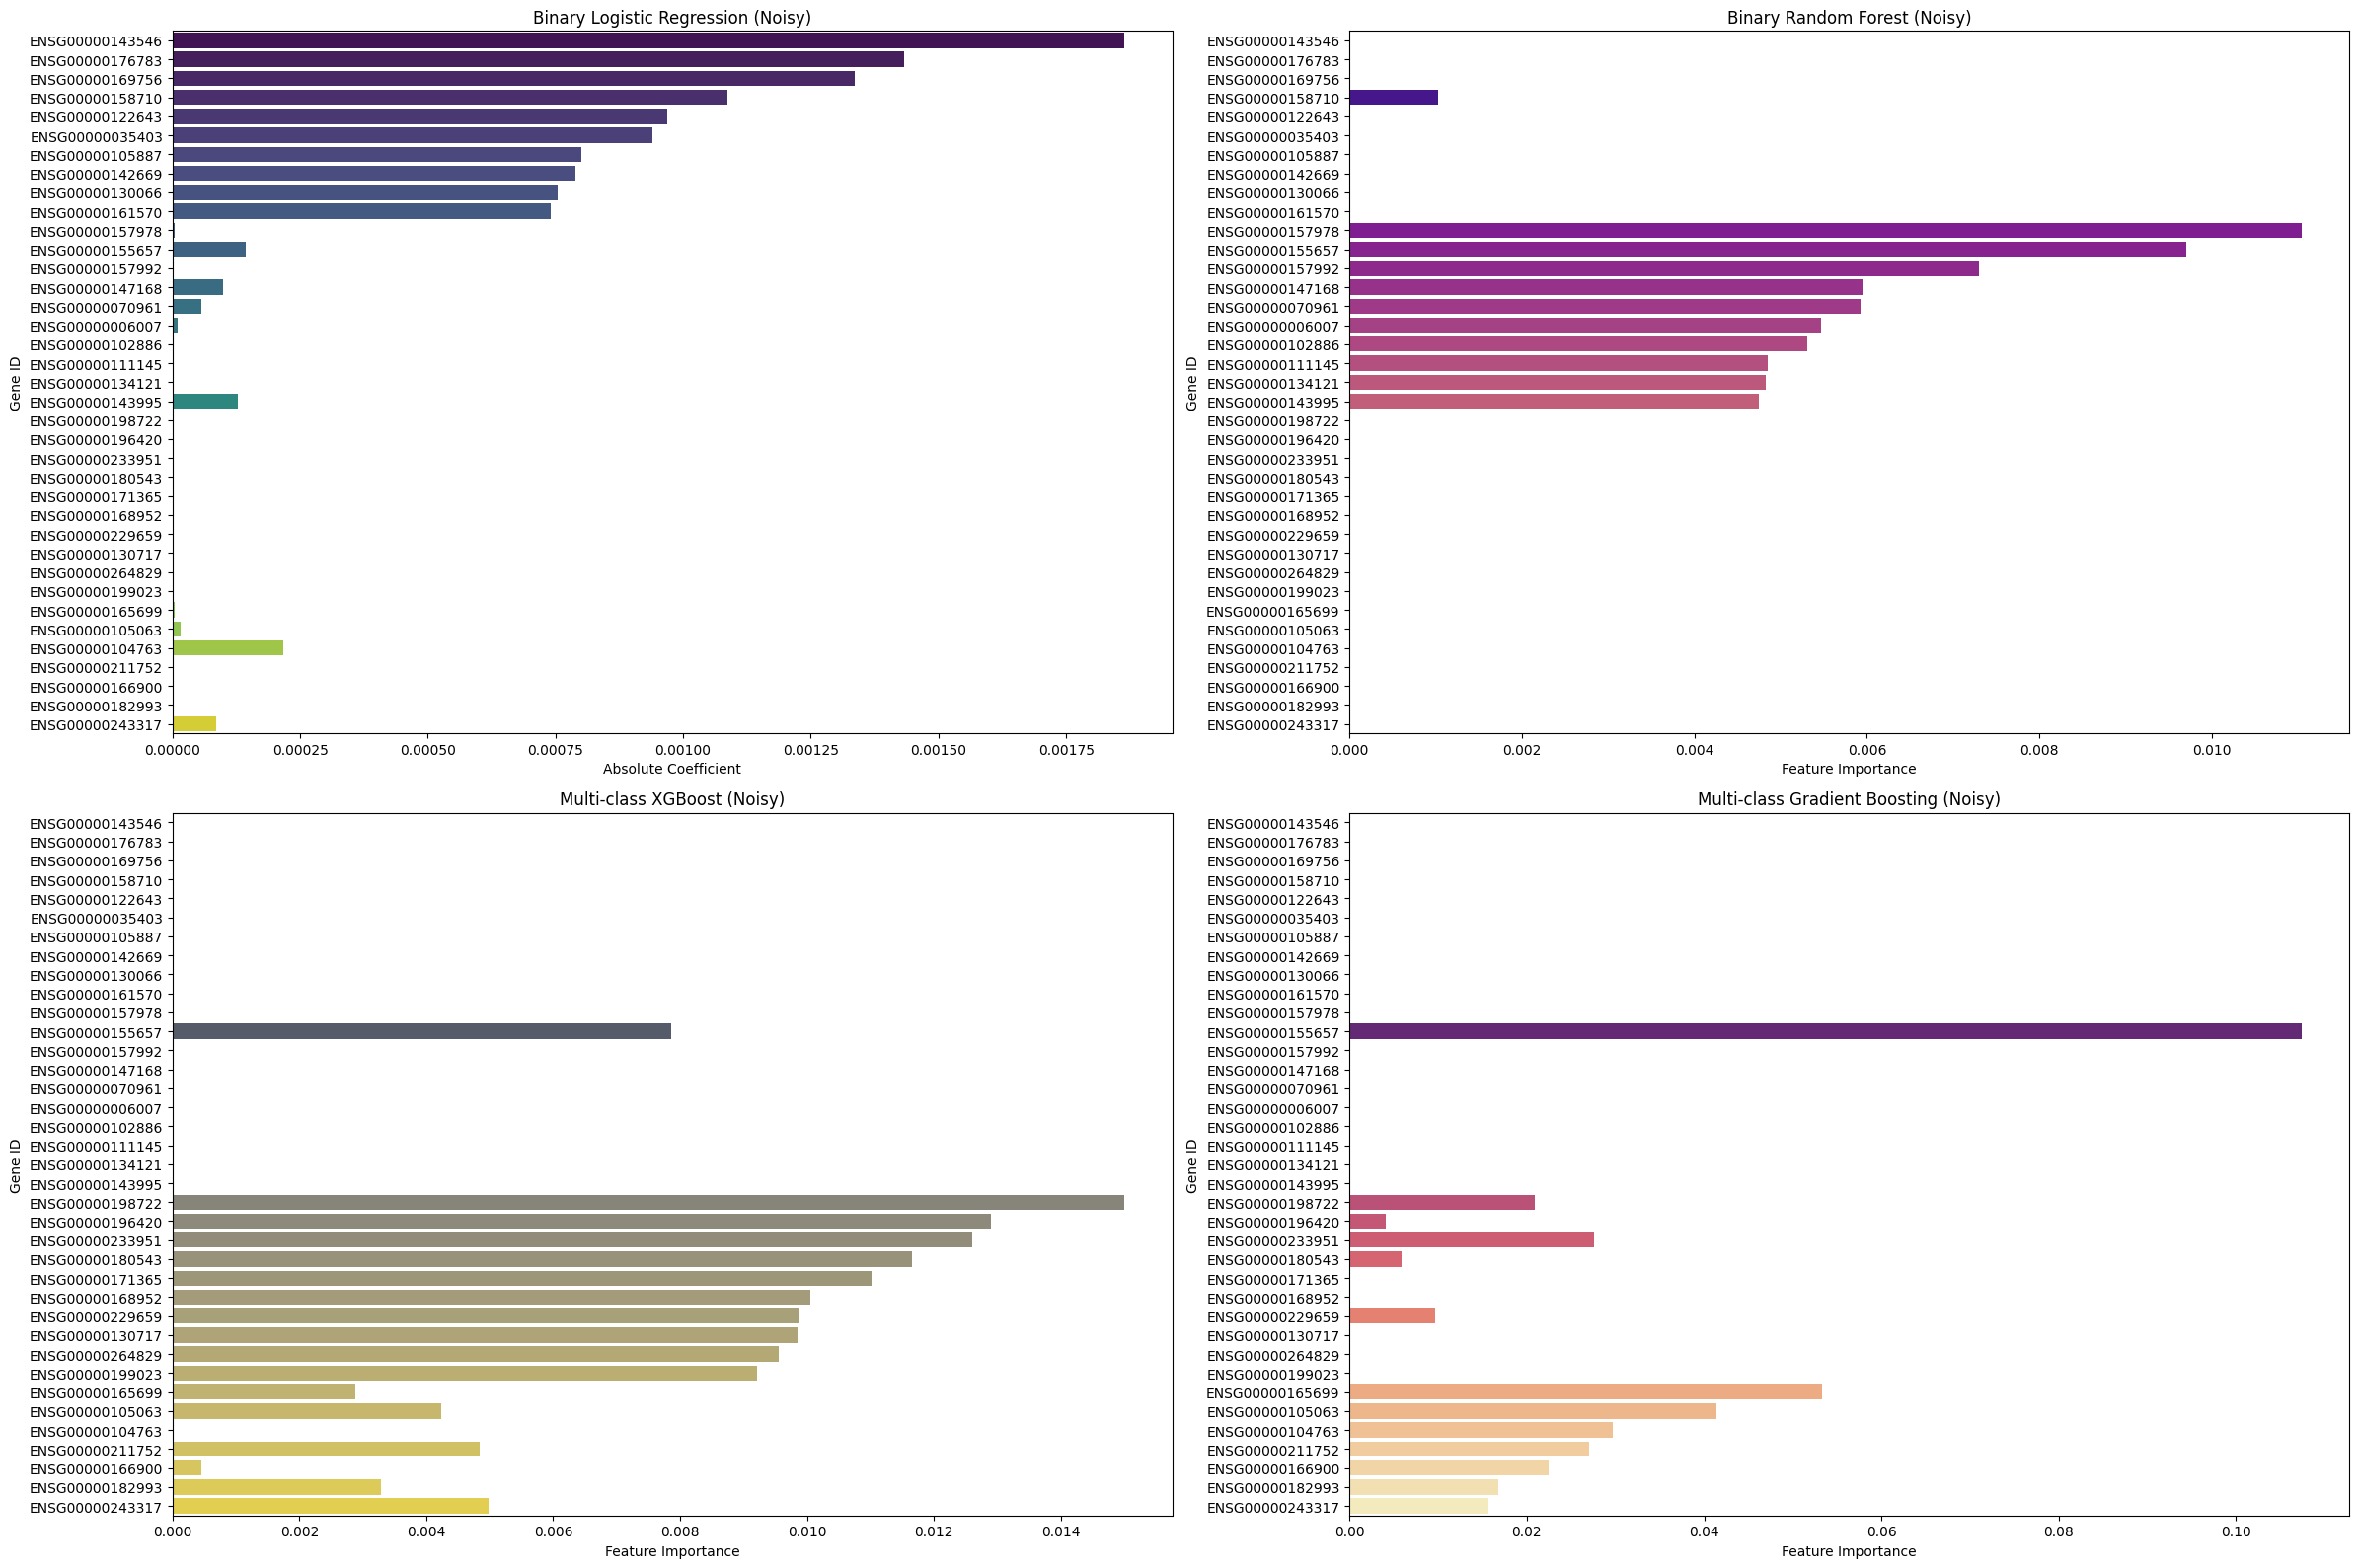

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# --- Feature Importance for Binary Logistic Regression (Noisy Data) ---
lr_feature_importance_noisy = pd.Series(
    logistic_model_binary_noisy.coef_[0],
    index=X_binary_noisy.columns
)

top_10_lr_features_noisy = lr_feature_importance_noisy.abs().nlargest(10)

print("\n--- Top 10 Features for Binary Logistic Regression (Noisy Data) ---")
print(top_10_lr_features_noisy.to_string())

# --- Feature Importance for Binary Random Forest (Noisy Data) ---
rf_feature_importance_noisy = pd.Series(
    rf_model_binary_noisy.feature_importances_,
    index=X_binary_noisy.columns
)

top_10_rf_features_noisy = rf_feature_importance_noisy.nlargest(10)

print("\n--- Top 10 Features for Binary Random Forest (Noisy Data) ---")
print(top_10_rf_features_noisy.to_string())

# --- Feature Importance for Multi-class XGBoost (Noisy Data) ---
xgb_multi_feature_importance_noisy = pd.Series(
    xgb_model_multi_noisy.feature_importances_,
    index=X_multi_noisy.columns
)

top_10_xgb_multi_features_noisy = xgb_multi_feature_importance_noisy.nlargest(10)

print("\n--- Top 10 Features for Multi-class XGBoost (Noisy Data) ---")
print(top_10_xgb_multi_features_noisy.to_string())

# --- Feature Importance for Multi-class Gradient Boosting Classifier (Noisy Data) ---
gbc_multi_feature_importance_noisy = pd.Series(
    gbc_model_multi_noisy.feature_importances_,
    index=X_multi_noisy.columns
)

top_10_gbc_multi_features_noisy = gbc_multi_feature_importance_noisy.nlargest(10)

print("\n--- Top 10 Features for Multi-class Gradient Boosting Classifier (Noisy Data) ---")
print(top_10_gbc_multi_features_noisy.to_string())

# --- Comparison with Best et al. (2015) ---
print("\n--- Common Features with Best et al. (2015) - Noisy Data ---")

common_lr_binary_noisy = set(top_10_lr_features_noisy.index) & set(best_paper_top_genes)
common_rf_binary_noisy = set(top_10_rf_features_noisy.index) & set(best_paper_top_genes)
common_xgb_multi_noisy = set(top_10_xgb_multi_features_noisy.index) & set(best_paper_top_genes)
common_gbc_multi_noisy = set(top_10_gbc_multi_features_noisy.index) & set(best_paper_top_genes)

print(f"Common genes with Best et al. in Binary Logistic Regression (Noisy): {common_lr_binary_noisy}")
print(f"Common genes with Best et al. in Binary Random Forest (Noisy): {common_rf_binary_noisy}")
print(f"Common genes with Best et al. in Multi-class XGBoost (Noisy): {common_xgb_multi_noisy}")
print(f"Common genes with Best et al. in Multi-class Gradient Boosting (Noisy): {common_gbc_multi_noisy}")

# --- Consolidated Top 10 Features Across All Models (Noisy Data) ---
print("\n--- Consolidated Top 10 Features Across All Models (Noisy Data) ---")

all_top_features_noisy = pd.DataFrame({
    'Binary LR (Noisy)': top_10_lr_features_noisy.index.tolist(),
    'Binary RF (Noisy)': top_10_rf_features_noisy.index.tolist(),
    'Multi-class XGBoost (Noisy)': top_10_xgb_multi_features_noisy.index.tolist(),
    'Multi-class GBC (Noisy)': top_10_gbc_multi_features_noisy.index.tolist()
})

display(all_top_features_noisy)

# --- Visualization ---
all_models_top_features_names_noisy = pd.Series(
    list(top_10_lr_features_noisy.index) +
    list(top_10_rf_features_noisy.index) +
    list(top_10_xgb_multi_features_noisy.index) +
    list(top_10_gbc_multi_features_noisy.index)
).unique()

fig, axes = plt.subplots(2, 2, figsize=(24, 16), sharex=False)
axes = axes.flatten()

# Binary Logistic Regression
plot_data_lr_binary_noisy = lr_feature_importance_noisy.loc[
    all_models_top_features_names_noisy
].abs().fillna(0)

sns.barplot(
    x=plot_data_lr_binary_noisy.values,
    y=plot_data_lr_binary_noisy.index,
    ax=axes[0],
    palette='viridis'
)

axes[0].set_title('Binary Logistic Regression (Noisy)')
axes[0].set_xlabel('Absolute Coefficient')
axes[0].set_ylabel('Gene ID')

# Binary Random Forest
plot_data_rf_binary_noisy = rf_feature_importance_noisy.loc[
    all_models_top_features_names_noisy
].fillna(0)

sns.barplot(
    x=plot_data_rf_binary_noisy.values,
    y=plot_data_rf_binary_noisy.index,
    ax=axes[1],
    palette='plasma'
)

axes[1].set_title('Binary Random Forest (Noisy)')
axes[1].set_xlabel('Feature Importance')
axes[1].set_ylabel('Gene ID')

# Multi-class XGBoost
plot_data_xgb_multi_noisy = xgb_multi_feature_importance_noisy.loc[
    all_models_top_features_names_noisy
].fillna(0)

sns.barplot(
    x=plot_data_xgb_multi_noisy.values,
    y=plot_data_xgb_multi_noisy.index,
    ax=axes[2],
    palette='cividis'
)

axes[2].set_title('Multi-class XGBoost (Noisy)')
axes[2].set_xlabel('Feature Importance')
axes[2].set_ylabel('Gene ID')

# Multi-class Gradient Boosting
plot_data_gbc_multi_noisy = gbc_multi_feature_importance_noisy.loc[
    all_models_top_features_names_noisy
].fillna(0)

sns.barplot(
    x=plot_data_gbc_multi_noisy.values,
    y=plot_data_gbc_multi_noisy.index,
    ax=axes[3],
    palette='magma'
)

axes[3].set_title('Multi-class Gradient Boosting (Noisy)')
axes[3].set_xlabel('Feature Importance')
axes[3].set_ylabel('Gene ID')

plt.tight_layout()
plt.show()

### Summary of Feature Importance Analysis with Noisy Data

After adding Gaussian noise to the input gene expression data and re-training the models, we performed the feature importance analysis again.

**Key Observations from Noisy Data Analysis:**

Binary Logistic Regression and Binary Random Forest: Both binary models continued to identify influential transcriptomic features for distinguishing healthy donors from cancer samples, although the ranking and magnitude of importance scores changed compared with the clean dataset, indicating sensitivity to added noise.

Multi-class XGBoost and Multi-class Gradient Boosting: The multiclass models also showed shifts in their most important genes after noise injection, suggesting that feature selection in multiclass classification is affected more noticeably by input perturbations.

Comparison with Clean Data: Some previously important genes remained influential after noise addition, while several new genes emerged, indicating partial robustness but also instability in feature rankings under noisy conditions.
Comparison with Best et al. (2015): No direct overlap was observed between the top noisy-data features and the predefined biomarker genes reported in Best et al. (2015).

These findings suggest that while the models retain predictive structure under noisy conditions, feature importance rankings are sensitive to data perturbation, highlighting the importance of robustness testing in biomarker discovery.

This re-analysis with noisy data provides insights into the stability and robustness of the identified important features. Significant changes in the top features could suggest that some identified genes are not robustly important but rather sensitive to minor data fluctuations. Conversely, genes that consistently appear as important across both original and noisy datasets may be considered more reliably predictive.